# Predicción de la calificación de reseñas en español con redes recurrentes

## 1. El problema

En una plataforma de comercio, el texto de una reseña y su calificación numérica deberían coincidir, pero no siempre lo hacen. Estimar la calificación a partir del texto sirve para detectar esas incoherencias, ordenar reseñas sin nota y resumir la opinión sobre un producto.

Dado el texto de una reseña en español, predecimos cuántas estrellas le corresponden, de 1 a 5.

### Las cinco clases tienen orden

Confundir 4 con 5 estrellas es un error leve; confundir 1 con 5 no lo es. Accuracy y F1 tratan ambos casos igual, porque asumen clases sin relación entre sí. Esto condiciona dos decisiones posteriores: las métricas de comparación y la lectura de la matriz de confusión.

### Pregunta de investigación

> ¿Cuánto aporta modelar la reseña como **secuencia** frente a tratarla como bolsa de palabras, y cuánto aporta además reutilizar **vectores de palabra preentrenados** del español?

### Hipótesis

Esperamos que las redes recurrentes superen a un modelo lineal sobre TF-IDF, porque la polaridad en español depende del orden: *no me gustó nada* y *me gustó, nada que objetar* comparten casi las mismas palabras y expresan lo contrario.

También esperamos que las clases intermedias (2, 3 y 4 estrellas) resulten más difíciles que los extremos.

---
## 2. Objetivos y alcance

### Objetivo general

Construir y comparar modelos de clasificación ordinal de reseñas en español, midiendo cuánto aporta cada nivel de complejidad añadido.

### Objetivos específicos

1. Explorar el corpus y caracterizar el vocabulario de cada nivel de calificación.
2. Establecer una referencia sin modelado secuencial con TF-IDF y regresión logística.
3. Entrenar y comparar LSTM, BiLSTM y GRU sobre embeddings aprendidos desde cero.
4. Incorporar un mecanismo de atención que permita inspeccionar en qué palabras se apoya el modelo.
5. Evaluar si inicializar los embeddings con vectores preentrenados del español mejora el resultado.
6. Comparar todo con métricas que respeten la naturaleza ordinal del problema.
7. Analizar los errores y construir una demo funcional.

### Alcance

Clasificación multiclase de etiqueta única sobre cinco niveles ordenados, con modelos lineales clásicos y redes recurrentes entrenadas desde cero.

---
## 3. Entorno y reproducibilidad

Fijamos una semilla global y también el generador del `DataLoader`. Sin esto el barajado de los lotes cambia entre ejecuciones aunque las semillas globales estén fijadas.

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules
print('Ejecutando en Colab:', IN_COLAB)

Ejecutando en Colab: True


In [2]:
if IN_COLAB:
    !pip install -q lightning torchmetrics gradio datasets spacy
    !python -m spacy download es_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 56.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 2.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import json
import random
import re
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchmetrics
from torch.utils.data import DataLoader, Dataset

try:
    import lightning.pytorch as pl
    from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
    from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger
except ImportError:
    import pytorch_lightning as pl
    from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
    from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

warnings.filterwarnings('ignore')

try:
    import tensorboard  # noqa: F401
    HAY_TENSORBOARD = True
except ImportError:
    HAY_TENSORBOARD = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
pl.seed_everything(SEED, workers=True)

# El generador del DataLoader tambien debe fijarse para que el barajado sea reproducible.
GENERADOR = torch.Generator().manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Dispositivo:', DEVICE)
print('PyTorch:', torch.__version__)
print('Lightning:', pl.__version__)
print('torchmetrics:', torchmetrics.__version__)
print('TensorBoard disponible:', HAY_TENSORBOARD)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Dispositivo: cuda
PyTorch: 2.11.0+cu128
Lightning: 2.6.6
torchmetrics: 1.9.0
TensorBoard disponible: True


---
## 4. Carga del corpus

Usamos un corpus de reseñas de productos en español del Hub de Hugging Face, con particiones oficiales de entrenamiento, validación y prueba. Las etiquetas vienen codificadas de 0 a 4 y las convertimos a estrellas de 1 a 5, para que el error absoluto medio se lea como *número de estrellas de desviación*.

In [4]:
from datasets import load_dataset

corpus = load_dataset('SetFit/amazon_reviews_multi_es')
print(corpus)

README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl: reconstructing file:   0%|          |  0.00B / 43.8MB            

train.jsonl: downloading bytes:           |  0.00B            

validation.jsonl:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})


In [5]:
CRUDOS = {nombre: corpus[nombre].to_pandas()[['text', 'label']].copy()
          for nombre in ('train', 'validation', 'test')}

for nombre, df in CRUDOS.items():
    print(f'{nombre:11s} {len(df):>6} reseñas')

print('\nPrimeras reseñas de entrenamiento:')
for _, fila in CRUDOS['train'].head(3).iterrows():
    print(f"  {fila['label'] + 1} estrellas | {fila['text'][:78]}")

train       200000 reseñas
validation    5000 reseñas
test          5000 reseñas

Primeras reseñas de entrenamiento:
  1 estrellas | Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuest
  1 estrellas | Horrible, nos tuvimos que comprar otro porque ni nosotros que sabemos inglés, 
  1 estrellas | Te obligan a comprar dos unidades y te llega solo una y no hay forma de reclam


---
## 5. Auditoría de integridad del corpus

Antes de mirar qué dicen las reseñas comprobamos si podemos fiarnos de los datos tal como vienen. Un problema de integridad no produce ningún error: el cuaderno se ejecuta igual y las métricas incluso salen mejores, pero contamina todo lo que venga después.

### 5.1 Reseñas repetidas y calificaciones ambiguas

Buscamos tres cosas, en orden de gravedad creciente:

1. **Reseñas repetidas dentro de una misma partición.** Un texto repetido pesa en el entrenamiento como si fueran opiniones independientes.
2. **Reseñas que aparecen en más de una partición.** Convertirían parte de la evaluación en una medida de memorización.
3. **Textos idénticos con calificaciones distintas.** Marcan un límite superior a lo que cualquier modelo puede aprender.

In [6]:
auditoria = []
for nombre, df in CRUDOS.items():
    textos = df['text'].astype(str).str.strip()
    repetidas = int(textos.duplicated().sum())
    auditoria.append({
        'partición': nombre,
        'reseñas': len(df),
        'nulas': int(df['text'].isna().sum()),
        'vacías': int((textos == '').sum()),
        'repetidas': repetidas,
        '% repetidas': round(100 * repetidas / len(df), 2),
    })

print(pd.DataFrame(auditoria).to_string(index=False))

conteo_textos = CRUDOS['train']['text'].value_counts()
print('\nReseñas más repetidas en entrenamiento:')
for texto, veces in conteo_textos.head(5).items():
    notas = sorted({int(e) + 1 for e in CRUDOS['train'].loc[CRUDOS['train']['text'] == texto, 'label']})
    print(f'  {veces:>4} veces | calificaciones observadas: {notas} | "{texto[:58]}"')

calificaciones_por_texto = CRUDOS['train'].groupby('text')['label'].nunique()
ambiguos = calificaciones_por_texto[calificaciones_por_texto > 1]
afectadas = int(CRUDOS['train']['text'].isin(ambiguos.index).sum())

print(f'\nTextos idénticos que aparecen con más de una calificación: {len(ambiguos)}')
print(f'Reseñas afectadas por esa ambigüedad: {afectadas} '
      f'({100 * afectadas / len(CRUDOS["train"]):.2f}% del entrenamiento)')

 partición  reseñas  nulas  vacías  repetidas  % repetidas
     train   200000      0       0       1736         0.87
validation     5000      0       0          5         0.10
      test     5000      0       0          6         0.12

Reseñas más repetidas en entrenamiento:
   106 veces | calificaciones observadas: [2, 3, 4, 5] | "Buena relación calidad precio"
    56 veces | calificaciones observadas: [3, 4, 5] | "Buena calidad precio"
    43 veces | calificaciones observadas: [1, 2, 3] | "No es lo que esperaba"
    27 veces | calificaciones observadas: [2, 3, 4, 5] | "Cumple las expectativas"
    24 veces | calificaciones observadas: [3, 4, 5] | "Buena relación calidad-precio"

Textos idénticos que aparecen con más de una calificación: 398
Reseñas afectadas por esa ambigüedad: 1654 (0.83% del entrenamiento)


### 5.2 ¿Están las particiones realmente separadas?

La tabla anterior mira cada partición por separado. Falta la comprobación que condiciona la validez del experimento: si un mismo texto aparece en dos particiones distintas.

Añadimos una segunda pregunta: cuando una reseña aparece en entrenamiento y en prueba, **¿lleva la misma calificación en las dos?**

Reseñas que aparecen en dos particiones a la vez:
  train ∩ validation       66
  train ∩ test             57
  validation ∩ test        9

Ejemplos presentes a la vez en entrenamiento y en prueba:
  entrenamiento=[4, 5]  prueba=[4]  |  "A mi hija le ha encantado"
  entrenamiento=[1, 4]  prueba=[2]  |  "Amazon, maquinaria sorda, envia tus productos a tiempo "
  entrenamiento=[1]  prueba=[1]  |  "Aun no lo he recibido"
  entrenamiento=[1]  prueba=[1]  |  "Aun no lo he recibido."
  entrenamiento=[1]  prueba=[1]  |  "Aun no me ha llegado"

De las 57 reseñas compartidas entre entrenamiento y prueba, 17 llevan la misma calificación y 40 llevan una distinta.


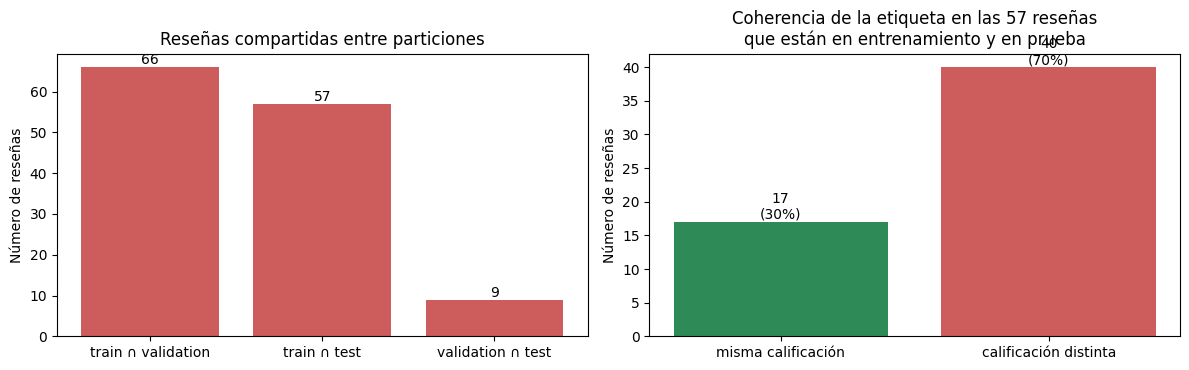

In [7]:
conjuntos = {nombre: set(df['text']) for nombre, df in CRUDOS.items()}
pares = [('train', 'validation'), ('train', 'test'), ('validation', 'test')]
solapamientos = {f'{a} ∩ {b}': len(conjuntos[a] & conjuntos[b]) for a, b in pares}

print('Reseñas que aparecen en dos particiones a la vez:')
for etiqueta, cuantas in solapamientos.items():
    print(f'  {etiqueta:24s} {cuantas}')

notas_train = CRUDOS['train'].groupby('text')['label'].agg(set)
notas_test = CRUDOS['test'].groupby('text')['label'].agg(set)
compartidos = sorted(set(notas_train.index) & set(notas_test.index))

print('\nEjemplos presentes a la vez en entrenamiento y en prueba:')
for texto in compartidos[:5]:
    en_train = sorted(int(e) + 1 for e in notas_train[texto])
    en_prueba = sorted(int(e) + 1 for e in notas_test[texto])
    print(f'  entrenamiento={en_train}  prueba={en_prueba}  |  "{texto[:55]}"')

misma_nota = sum(1 for t in compartidos if notas_train[t] == notas_test[t])
distinta_nota = len(compartidos) - misma_nota
print(f'\nDe las {len(compartidos)} reseñas compartidas entre entrenamiento y prueba, '
      f'{misma_nota} llevan la misma calificación y {distinta_nota} llevan una distinta.')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].bar(list(solapamientos), list(solapamientos.values()), color='indianred')
axes[0].set_title('Reseñas compartidas entre particiones')
axes[0].set_ylabel('Número de reseñas')
for i, valor in enumerate(solapamientos.values()):
    axes[0].text(i, valor, str(valor), ha='center', va='bottom')

axes[1].bar(['misma calificación', 'calificación distinta'], [misma_nota, distinta_nota],
            color=['seagreen', 'indianred'])
axes[1].set_title(f'Coherencia de la etiqueta en las {len(compartidos)} reseñas\n'
                  'que están en entrenamiento y en prueba')
axes[1].set_ylabel('Número de reseñas')
for i, valor in enumerate([misma_nota, distinta_nota]):
    axes[1].text(i, valor, f'{valor}\n({valor / len(compartidos):.0%})', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Qué implican estos hallazgos

Los tres problemas afectan a menos del 1% de las reseñas, pero cada uno exige una respuesta distinta.

Las **reseñas repetidas** son las menos graves: el 0,87% del entrenamiento. Basta con quedarnos con una copia de cada texto. *"Buena relación calidad precio"* aparece 106 veces y pesaría como 106 opiniones independientes.

Las **reseñas compartidas entre particiones** sí son un problema serio, aunque sean 66 y 57. El modelo las habría visto con su etiqueta antes de que se le evalúe con ellas, y la evaluación mediría memorización en parte. Es un fallo silencioso: solo produce métricas mejores de lo que corresponde.

El tercer hallazgo no se puede corregir. Hay 398 textos con más de una calificación, que afectan a 1.654 reseñas, y de las 57 presentes a la vez en entrenamiento y prueba **40 llevan notas distintas en cada partición**. *"No es lo que esperaba"* aparece con una, dos o tres estrellas, y *"Cumple las expectativas"* con dos, tres, cuatro o cinco.

Es decir, **la etiqueta no es una función del texto**. Ningún modelo puede acertar en los dos casos a la vez, así que hay un techo de desempeño que no depende de la arquitectura.

Depuramos **antes** del muestreo: si muestreáramos primero las diez mil reseñas por clase y elimináramos después, las clases dejarían de estar balanceadas.

### 5.3 Depuración y muestreo

Aplicamos las dos decisiones que se derivan de la auditoría: eliminamos los textos repetidos dentro de cada partición y descartamos del entrenamiento las reseñas que reaparecen en validación o en prueba. El muestreo balanceado de diez mil reseñas por clase se hace al final, sobre el material ya depurado.

Sobre las calificaciones ambiguas no actuamos: no podemos decidir cuál de las dos notas es la correcta.

In [8]:
N_POR_CLASE = 10_000
COLUMNAS = ['text', 'label', 'estrellas']


def limpiar(df):
    df = df.copy()
    df['text'] = df['text'].astype(str).str.strip()
    return df[df['text'] != ''].drop_duplicates(subset='text')


def preparar(df, n_por_clase=None, excluir=None):
    if excluir is not None:
        df = df[~df['text'].isin(excluir)]
    if n_por_clase is not None:
        df = (df.groupby('label', group_keys=False)
                .apply(lambda g: g.sample(n_por_clase, random_state=SEED)))
    df = df.copy()
    df['estrellas'] = df['label'] + 1
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)[COLUMNAS]


sin_repetir = {nombre: limpiar(df) for nombre, df in CRUDOS.items()}
reservados = set(sin_repetir['validation']['text']) | set(sin_repetir['test']['text'])
descartadas = int(sin_repetir['train']['text'].isin(reservados).sum())

val_df = preparar(sin_repetir['validation'])
test_df = preparar(sin_repetir['test'])
train_df = preparar(sin_repetir['train'], N_POR_CLASE, excluir=reservados)

CLASES = sorted(int(c) for c in train_df['estrellas'].unique())
NUM_CLASES = len(CLASES)

resumen_depuracion = pd.DataFrame([
    {'partición': nombre, 'original': len(CRUDOS[nombre]),
     'sin repetidas': len(sin_repetir[nombre]), 'final': len(final)}
    for nombre, final in [('train', train_df), ('validation', val_df), ('test', test_df)]
])

print(resumen_depuracion.to_string(index=False))
print(f'\nReseñas descartadas del entrenamiento por aparecer en validación o prueba: {descartadas}')
print('Calificaciones presentes:', CLASES)
train_df.head()

 partición  original  sin repetidas  final
     train    200000         198264  50000
validation      5000           4995   4995
      test      5000           4994   4994

Reseñas descartadas del entrenamiento por aparecer en validación o prueba: 117
Calificaciones presentes: [1, 2, 3, 4, 5]


,text,label,estrellas
0,ES PERFECTA PARA LAS NECESIDADES QUE YO TENGO....,3,4
1,Tenía muchas ganas de probar estos sabores ya ...,0,1
2,"No funcionaba bien, lo devolví.",0,1
3,Después de dos meses de poco uso ya se ha estr...,1,2
4,"A pesar de lo pequeño que es, muy practico y t...",3,4


### 5.4 Verificación posterior

Comprobamos que la depuración surtió efecto.

In [9]:
for nombre, df in [('train', train_df), ('validación', val_df), ('prueba', test_df)]:
    vacios = (df['text'].astype(str).str.strip() == '').sum()
    duplicados = df['text'].duplicated().sum()
    print(f'{nombre:11s} nulos={df.isna().sum().sum():4d}  vacíos={vacios:4d}  duplicados={duplicados:4d}')

fuga_val = set(train_df['text']) & set(val_df['text'])
fuga_test = set(train_df['text']) & set(test_df['text'])

print(f'\nTextos compartidos entrenamiento-validación: {len(fuga_val)}')
print(f'Textos compartidos entrenamiento-prueba:     {len(fuga_test)}')

print('\nRegistros por clase en entrenamiento:')
print(train_df['estrellas'].value_counts().sort_index().to_string())

assert train_df['text'].notna().all(), 'Hay textos nulos'
assert not fuga_val and not fuga_test, 'Queda fuga de información entre particiones'
assert train_df['estrellas'].value_counts().nunique() == 1, 'Las clases no quedaron balanceadas'

train       nulos=   0  vacíos=   0  duplicados=   0
validación  nulos=   0  vacíos=   0  duplicados=   0
prueba      nulos=   0  vacíos=   0  duplicados=   0

Textos compartidos entrenamiento-validación: 0
Textos compartidos entrenamiento-prueba:     0

Registros por clase en entrenamiento:
estrellas
1    10000
2    10000
3    10000
4    10000
5    10000


---
## 6. Análisis exploratorio

### 6.1 Distribución de las calificaciones

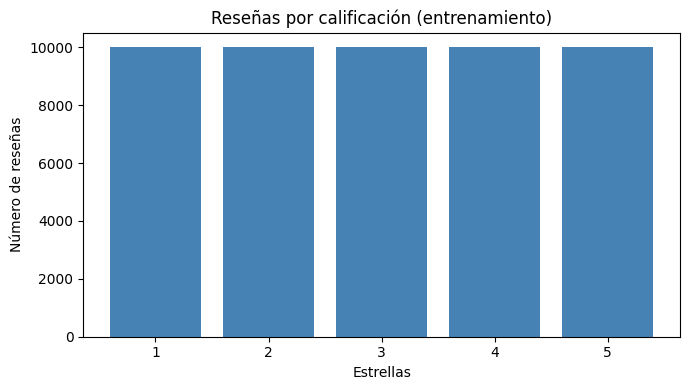

estrellas
1    10000
2    10000
3    10000
4    10000
5    10000


In [10]:
conteo = train_df['estrellas'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(conteo.index, conteo.values, color='steelblue')
ax.set_title('Reseñas por calificación (entrenamiento)')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Número de reseñas')
ax.set_xticks(CLASES)
plt.tight_layout()
plt.show()

print(conteo.to_string())

Diez mil reseñas por clase, exactamente. Un clasificador al azar acertaría en torno al 20%, que es el piso contra el que comparar. Además ninguna métrica quedará inflada por una clase mayoritaria.

### 6.2 Longitud de las reseñas

Necesitamos esta distribución para decidir dónde cortar las secuencias. La miramos también **por clase**, para ver si quien está descontento escribe más.

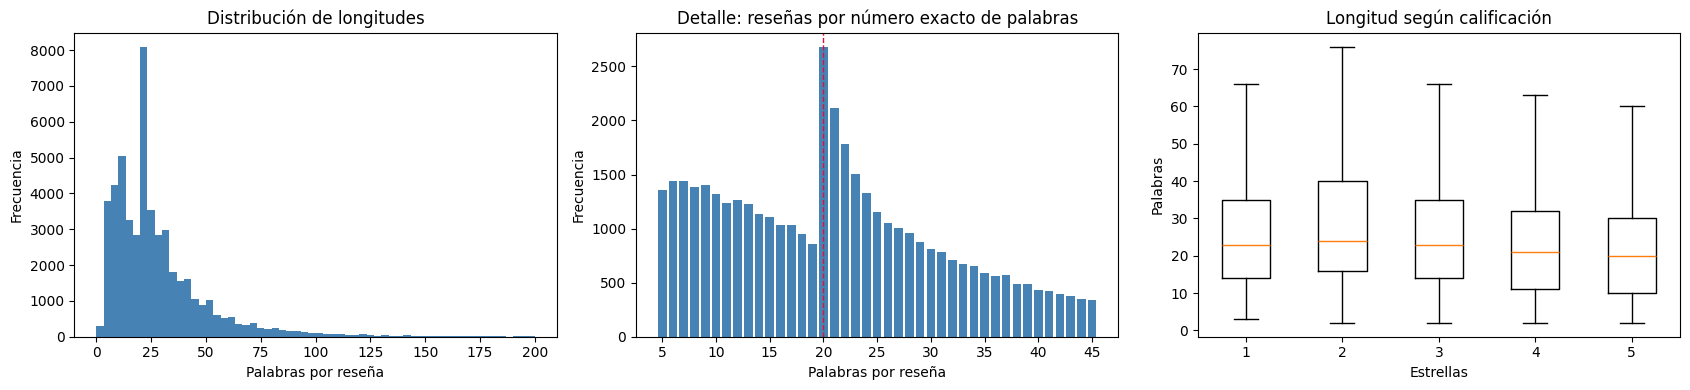

p50        22.0
p75        34.0
p90        54.0
p95        73.0
p99       123.0
media      28.1
máximo    474.0

Mediana de palabras por clase:
estrellas
1    23.0
2    24.0
3    23.0
4    21.0
5    20.0

Reseñas por número exacto de palabras alrededor del escalón:
n_palabras
17    1033
18     948
19     856
20    2677
21    2112
22    1783
23    1504

Salto entre 19 y 20 palabras: x3.13


In [11]:
train_df['n_palabras'] = train_df['text'].astype(str).str.split().str.len()

percentiles = [50, 75, 90, 95, 99]
resumen_long = pd.Series({f'p{p}': np.percentile(train_df['n_palabras'], p) for p in percentiles})
resumen_long['media'] = train_df['n_palabras'].mean()
resumen_long['máximo'] = train_df['n_palabras'].max()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(train_df['n_palabras'], bins=60, range=(0, 200), color='steelblue')
axes[0].set_title('Distribución de longitudes')
axes[0].set_xlabel('Palabras por reseña')
axes[0].set_ylabel('Frecuencia')

# Un intervalo por palabra: con intervalos más anchos el escalón de las 20 palabras se difumina.
exactas = train_df['n_palabras'].value_counts().sort_index()
tramo = exactas.loc[5:45]
axes[1].bar(tramo.index, tramo.values, color='steelblue')
axes[1].axvline(20, color='crimson', linestyle='--', linewidth=1)
axes[1].set_title('Detalle: reseñas por número exacto de palabras')
axes[1].set_xlabel('Palabras por reseña')
axes[1].set_ylabel('Frecuencia')

datos_por_clase = [train_df.loc[train_df['estrellas'] == c, 'n_palabras'] for c in CLASES]
axes[2].boxplot(datos_por_clase, tick_labels=CLASES, showfliers=False)
axes[2].set_title('Longitud según calificación')
axes[2].set_xlabel('Estrellas')
axes[2].set_ylabel('Palabras')

plt.tight_layout()
plt.show()

print(resumen_long.round(1).to_string())
print('\nMediana de palabras por clase:')
print(train_df.groupby('estrellas')['n_palabras'].median().to_string())
print('\nReseñas por número exacto de palabras alrededor del escalón:')
print(exactas.loc[17:23].to_string())
print(f'\nSalto entre 19 y 20 palabras: x{exactas.get(20, 0) / exactas.get(19, 1):.2f}')

La distribución tiene una cola muy larga: mediana de 22 palabras, percentil 95 en 73, percentil 99 en 123 y máximo en 474. Cortar por el percentil 95 parece razonable.

### Un escalón en las veinte palabras

Contando reseñas por número **exacto** de palabras, la serie se mantiene en torno a las 1.400 hasta las doce palabras, desciende hasta las 856 en las diecinueve y **salta a 2.677 en las veinte**, más del triple que el valor anterior. Después retoma el descenso suave: 2.112, 1.783, 1.504.

Una distribución de longitudes de texto libre debería ser más continua. Un salto de esa magnitud en un valor tan redondo apunta a un artefacto de construcción del corpus, probablemente un requisito de longitud mínima en la plataforma de origen.

### Longitud y descontento

Las medianas por clase son 23, 24, 23, 21 y 20 palabras de una a cinco estrellas. **Hay tendencia, pero es débil**: tres o cuatro palabras de diferencia entre las negativas y las entusiastas.

El diagrama de cajas añade un matiz: la clase de dos estrellas es la de **mayor dispersión**, con el cuartil superior en torno a las 40 palabras, y la de cinco la más compacta. El entusiasmo se expresa de forma breve y homogénea; la insatisfacción moderada admite desde una línea hasta un relato extenso.

La diferencia es demasiado pequeña para que la longitud sirva por sí sola como señal predictiva.

Conviene precisar que estas longitudes son **palabras separadas por espacios del texto original**. La que determinará el corte de las secuencias es la del texto tokenizado, que separa la puntuación y cambia el recuento.

### 6.3 Vocabulario más frecuente

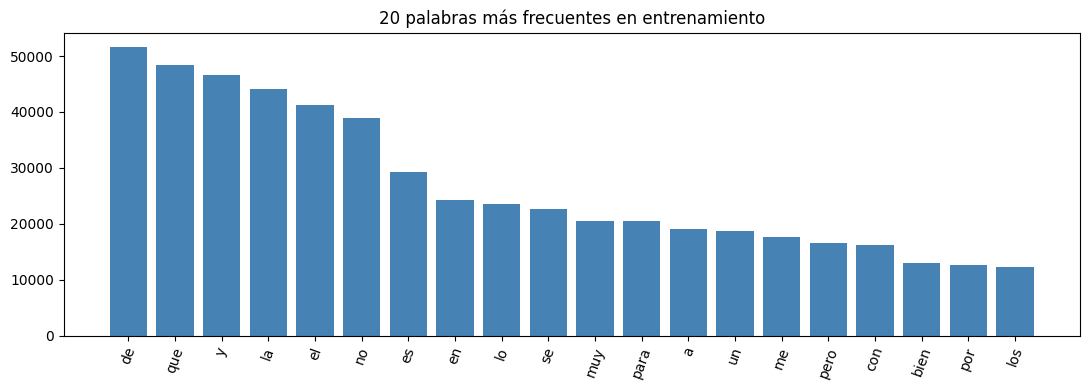

Palabras distintas en entrenamiento: 33096


In [12]:
PATRON_LIMPIEZA = re.compile(r'[^a-záéíóúüñ0-9\s]')


def tokenizar(texto):
    texto = PATRON_LIMPIEZA.sub(' ', str(texto).lower())
    return texto.split()


contador_global = Counter()
for texto in train_df['text']:
    contador_global.update(tokenizar(texto))

top_global = pd.DataFrame(contador_global.most_common(20), columns=['palabra', 'frecuencia'])

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(top_global['palabra'], top_global['frecuencia'], color='steelblue')
ax.set_title('20 palabras más frecuentes en entrenamiento')
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.show()

print('Palabras distintas en entrenamiento:', len(contador_global))

Las 50.000 reseñas contienen 33.096 palabras distintas y el ranking lo encabezan artículos, preposiciones y conjunciones.

**La sexta palabra más frecuente es *no***, con unas 39.000 apariciones, por delante de *es*, *en*, *lo* y *se*. Es la única con carga semántica propia entre las diez primeras. Algo más abajo, en los puestos dieciséis y dieciocho, aparecen *pero* y *bien*.

Que una negación y un adversativo figuren entre las veinte palabras más usadas indica que buena parte de lo que se dice aquí se construye negando o contraponiendo.

### 6.4 Palabras que distinguen cada calificación

En lugar de la frecuencia bruta usamos la prueba **chi cuadrado** de cada palabra frente a la pertenencia a una clase. Responde a una pregunta distinta: no qué palabras aparecen mucho, sino cuáles aparecen desproporcionadamente en un nivel de calificación.

In [13]:
vectorizador_conteo = CountVectorizer(min_df=20, tokenizer=tokenizar, lowercase=False)
X_conteo = vectorizador_conteo.fit_transform(train_df['text'])
terminos = np.array(vectorizador_conteo.get_feature_names_out())

discriminativas = {}
for clase in CLASES:
    objetivo = (train_df['estrellas'] == clase).astype(int)
    puntajes, _ = chi2(X_conteo, objetivo)
    puntajes = np.nan_to_num(puntajes)
    # Solo interesan las palabras sobrerrepresentadas en la clase, no las ausentes.
    media_clase = np.asarray(X_conteo[objetivo.values == 1].mean(axis=0)).ravel()
    media_resto = np.asarray(X_conteo[objetivo.values == 0].mean(axis=0)).ravel()
    puntajes = np.where(media_clase > media_resto, puntajes, 0)
    discriminativas[clase] = terminos[np.argsort(puntajes)[::-1][:12]]

pd.DataFrame(discriminativas).rename(columns=lambda c: f'{c} estrellas')

,1 estrellas,2 estrellas,3 estrellas,4 estrellas,5 estrellas
0,no,no,pero,bien,perfecto
1,nada,la,bien,buena,muy
2,dinero,se,poco,buen,genial
3,ni,pero,es,precio,encantado
4,llegado,que,más,cumple,buena
5,amazon,el,está,única,buen
6,me,al,algo,relación,recomendable
7,nunca,de,demasiado,único,encanta
8,esperando,si,esperaba,perfectamente,perfecta
9,recibido,dos,demás,pega,perfectamente


**Los extremos tienen vocabulario propio.** Las cinco estrellas se identifican con *perfecto*, *genial*, *encantado*, *recomendable*, *excelente*, *encanta*: adjetivos entusiastas y sin matices.

**Una estrella habla de logística, no de producto.** Sus palabras más discriminativas son *dinero*, *llegado*, *amazon*, *nunca*, *esperando*, *recibido*, *vendedor*. La insatisfacción extrema en este corpus no suele referirse a que el artículo sea malo, sino a que no llegó, llegó tarde o hubo que reclamar el dinero.

**Las clases intermedias se apoyan en matizadores.** Tres estrellas se caracteriza por *pero*, *bien*, *poco*, *algo*, *demasiado*, *esperaba*, *aunque*: la única palabra de valoración aparece rodeada de matices que la relativizan. Y los términos más discriminativos de dos estrellas son *la*, *se*, *que*, *el*, *al*, *de*, *si*, *del*, *por*, casi todas funcionales. **La clase de dos estrellas carece de vocabulario propio**: no se define por lo que dice sino por no ser ninguna de las otras.

Esto anticipa que los errores no se repartirán al azar y que las clases intermedias serán las difíciles.

### 6.5 Bigramas y negaciones

Si el orden de las palabras importa, debería verse en los bigramas frecuentes y en el uso de negaciones y conectores adversativos según la calificación.

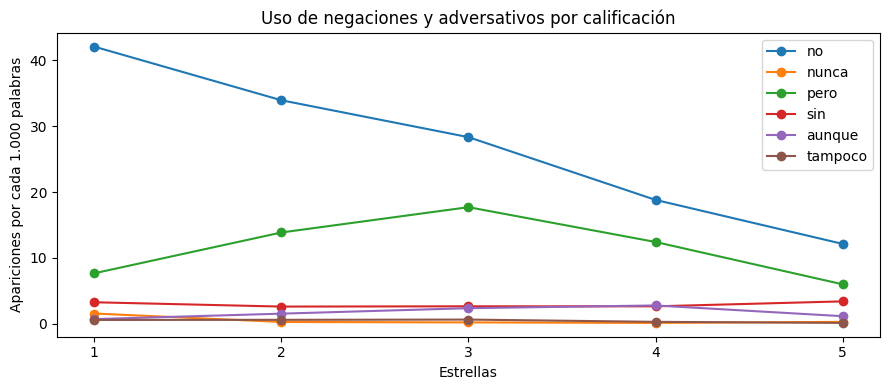

Bigramas más frecuentes:
    bigrama  frecuencia
     lo que        5368
      de la        4520
      en la        4161
      no se        4113
     que no        3907
       y no        3729
   muy bien        3585
      no me        3523
      no es        3522
     es muy        3475
    un poco        3315
      en el        3275
      me ha        3110
       a la        3073
el producto        2847

Marcadores por cada 1.000 palabras:
      no  nunca   pero   sin  aunque  tampoco
1  42.07   1.56   7.67  3.27    0.71     0.59
2  33.93   0.28  13.86  2.61    1.54     0.61
3  28.33   0.21  17.70  2.66    2.37     0.64
4  18.81   0.14  12.42  2.65    2.79     0.30
5  12.13   0.29   6.00  3.41    1.16     0.14


In [14]:
vec_bigramas = CountVectorizer(ngram_range=(2, 2), min_df=30, tokenizer=tokenizar, lowercase=False)
X_bi = vec_bigramas.fit_transform(train_df['text'])
frec_bi = np.asarray(X_bi.sum(axis=0)).ravel()
nombres_bi = np.array(vec_bigramas.get_feature_names_out())
orden = np.argsort(frec_bi)[::-1][:15]

MARCADORES = ['no', 'nunca', 'pero', 'sin', 'aunque', 'tampoco']
uso_marcadores = pd.DataFrame(index=CLASES, columns=MARCADORES, dtype=float)
for clase in CLASES:
    textos = train_df.loc[train_df['estrellas'] == clase, 'text']
    conteo_clase = Counter()
    total_tokens = 0
    for t in textos:
        tokens = tokenizar(t)
        total_tokens += len(tokens)
        conteo_clase.update(tokens)
    for m in MARCADORES:
        uso_marcadores.loc[clase, m] = 1000 * conteo_clase[m] / total_tokens

fig, ax = plt.subplots(figsize=(9, 4))
for m in MARCADORES:
    ax.plot(CLASES, uso_marcadores[m], marker='o', label=m)
ax.set_title('Uso de negaciones y adversativos por calificación')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Apariciones por cada 1.000 palabras')
ax.set_xticks(CLASES)
ax.legend()
plt.tight_layout()
plt.show()

print('Bigramas más frecuentes:')
print(pd.DataFrame({'bigrama': nombres_bi[orden], 'frecuencia': frec_bi[orden]}).to_string(index=False))
print('\nMarcadores por cada 1.000 palabras:')
print(uso_marcadores.round(2).to_string())

**Cinco de los quince bigramas más frecuentes contienen una negación**: *no se* (4.113), *que no* (3.907), *y no* (3.729), *no me* (3.523) y *no es* (3.522). La negación es parte de la estructura básica de este corpus.

**El uso de *no* cae de forma monótona con la calificación**: 42,07 apariciones por cada mil palabras en una estrella, 33,93 en dos, 28,33 en tres, 18,81 en cuatro y 12,13 en cinco. Una pendiente limpia, sin excepciones.

**El *pero* dibuja una campana centrada en las tres estrellas**: 7,67 en una estrella, 13,86 en dos, máximo de 17,70 en tres, y de nuevo 12,42 y 6,00. El adversativo es la herramienta de quien tiene algo bueno y algo malo que decir; las opiniones tajantes no necesitan matizar.

### 6.6 Solapamiento de vocabulario entre clases

Medimos cuánto se parecen los vocabularios de cada par de calificaciones con el índice de Jaccard sobre sus doscientas palabras de contenido más frecuentes.

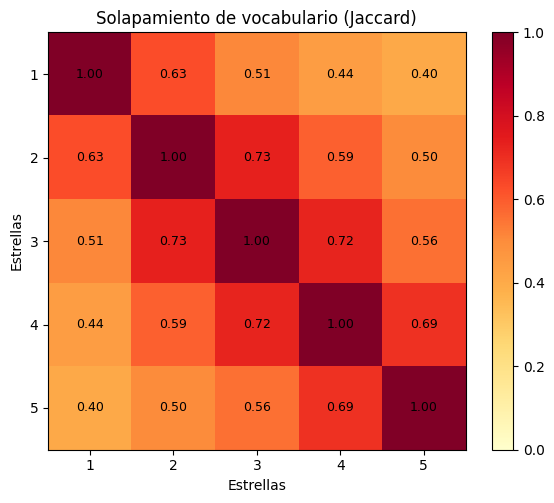

In [15]:
FUNCIONALES = {'de', 'la', 'el', 'los', 'las', 'un', 'una', 'y', 'o', 'que', 'en', 'por',
               'para', 'con', 'del', 'al', 'se', 'es', 'lo', 'a', 'me', 'mi', 'su', 'te'}

top_por_clase = {}
for clase in CLASES:
    conteo_clase = Counter()
    for t in train_df.loc[train_df['estrellas'] == clase, 'text']:
        conteo_clase.update(w for w in tokenizar(t) if w not in FUNCIONALES and len(w) > 2)
    top_por_clase[clase] = {w for w, _ in conteo_clase.most_common(200)}

jaccard = pd.DataFrame(index=CLASES, columns=CLASES, dtype=float)
for a in CLASES:
    for b in CLASES:
        interseccion = len(top_por_clase[a] & top_por_clase[b])
        union = len(top_por_clase[a] | top_por_clase[b])
        jaccard.loc[a, b] = interseccion / union

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jaccard.values.astype(float), cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASES), CLASES)
ax.set_yticks(range(NUM_CLASES), CLASES)
ax.set_title('Solapamiento de vocabulario (Jaccard)')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Estrellas')
for i in range(NUM_CLASES):
    for j in range(NUM_CLASES):
        ax.text(j, i, f'{jaccard.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Hay una banda caliente alrededor de la diagonal y el parecido decae al alejarse de ella.

Las calificaciones contiguas comparten prácticamente el mismo vocabulario: los pares 2–3 y 3–4 alcanzan 0,73 y 0,72, **casi tres de cada cuatro palabras frecuentes en común**. Los pares 1–2 y 4–5 quedan en 0,63 y 0,69. Las reseñas de una y cinco estrellas son las más distintas entre sí, con 0,40.

Si este solapamiento afecta a los modelos, cabría esperar que el error se concentre entre calificaciones vecinas y que las confusiones entre extremos sean escasas.

También importa al elegir las métricas: si las clases vecinas son léxicamente casi indistinguibles, una métrica que trate por igual el error de una estrella y el de cuatro describirá mal lo que hace el modelo.

### 6.7 El espacio de vectores preentrenados

Hasta aquí hemos mirado el corpus por frecuencias. Ahora lo miramos desde la semántica, con los vectores de palabra del modelo grande de spaCy para el español. Lo cargamos aquí porque los mismos vectores se usan después para inicializar la capa de embeddings.

In [16]:
import spacy

nlp = spacy.load('es_core_news_lg')
print('Vectores disponibles:', nlp.vocab.vectors.shape)


def similitud(a, b):
    va, vb = nlp.vocab[a].vector, nlp.vocab[b].vector
    na, nb = np.linalg.norm(va), np.linalg.norm(vb)
    return float(va @ vb / (na * nb)) if na and nb else 0.0


PARES = [
    ('pésimo', 'defectuoso'),
    ('bueno', 'excelente'),
    ('bueno', 'correcto'),
    ('correcto', 'aceptable'),
    ('excelente', 'perfecto'),
    ('malo', 'bueno'),
    ('malo', 'pésimo'),
    ('caro', 'barato'),
]
for a, b in PARES:
    print(f'{a:11s} ~ {b:12s} {similitud(a, b): .3f}')

Vectores disponibles: (500000, 300)
pésimo      ~ defectuoso    0.237
bueno       ~ excelente     0.417
bueno       ~ correcto      0.481
correcto    ~ aceptable     0.674
excelente   ~ perfecto      0.671
malo        ~ bueno         0.758
malo        ~ pésimo        0.470
caro        ~ barato        0.787


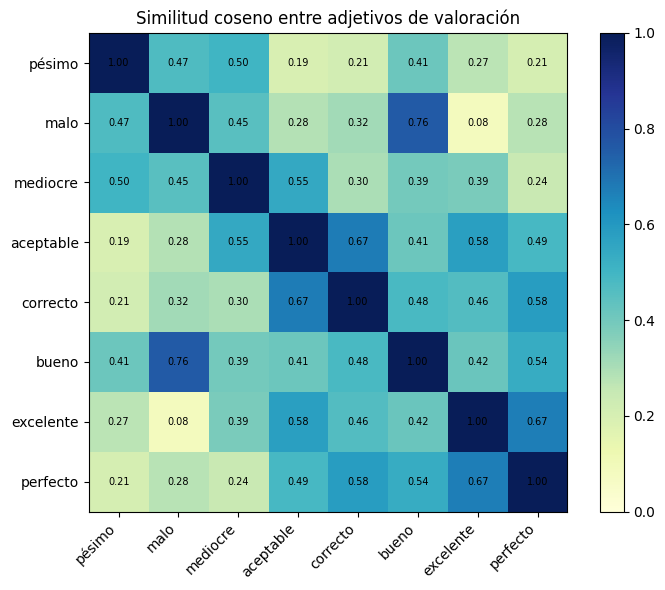

In [17]:
ESCALA = ['pésimo', 'malo', 'mediocre', 'aceptable', 'correcto', 'bueno', 'excelente', 'perfecto']

matriz_escala = pd.DataFrame(
    [[similitud(a, b) for b in ESCALA] for a in ESCALA], index=ESCALA, columns=ESCALA
)

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(matriz_escala.values, cmap='YlGnBu', vmin=0, vmax=1)
ax.set_xticks(range(len(ESCALA)), ESCALA, rotation=45, ha='right')
ax.set_yticks(range(len(ESCALA)), ESCALA)
ax.set_title('Similitud coseno entre adjetivos de valoración')
for i in range(len(ESCALA)):
    for j in range(len(ESCALA)):
        ax.text(j, i, f'{matriz_escala.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Los 500.000 vectores de 300 dimensiones dejan dos observaciones.

**Los adjetivos contiguos en la escala están muy juntos.** *Correcto* y *aceptable* alcanzan 0,674 de similitud, y *excelente* y *perfecto* 0,671. Las palabras que deberían separar cuatro estrellas de cinco ocupan casi el mismo punto del espacio.

**El espacio no parece codificar la polaridad.** *Malo* y *bueno* tienen una similitud de **0,758**, y *caro* y *barato* de **0,787**: los dos valores más altos de la tabla, por encima de cualquier par de sinónimos. En cambio *pésimo* y *defectuoso* se quedan en 0,237, y *bueno* y *excelente* en 0,417.

Esto ocurre porque los vectores se estiman por contexto de uso, y los antónimos aparecen en contextos muy parecidos (*el producto es ___*). Capturan de qué se habla más que qué se opina.

Nos hace dudar de que ayuden en el tercer nivel del experimento: inicializaríamos los embeddings con una representación que coloca *bueno* y *malo* casi en el mismo sitio, en una tarea que consiste en distinguir lo bueno de lo malo. Lo comprobamos en la sección 14.

---
## 7. Cómo medimos

Las clases están ordenadas y los errores se concentrarán entre calificaciones vecinas. Accuracy y F1 son ciegas a esa estructura, así que añadimos dos métricas que sí la capturan:

- **MAE en estrellas**: a cuántas estrellas de distancia se equivoca el modelo en promedio.
- **Kappa cuadrático ponderado (QWK)**: penaliza cada error en proporción al cuadrado de la distancia entre la clase real y la predicha.

Dos modelos pueden tener un F1 casi idéntico y un MAE muy distinto; en ese caso preferimos el que se equivoca cerca.

In [18]:
def evaluar(nombre, y_real, y_pred, segundos=None):
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(y_real, y_pred),
        'f1_macro': f1_score(y_real, y_pred, average='macro'),
        'mae_estrellas': mean_absolute_error(y_real, y_pred),
        'qwk': cohen_kappa_score(y_real, y_pred, weights='quadratic'),
        'segundos': segundos,
    }


resultados_val = []

---
## 8. Primer nivel: un modelo que ignora el orden

Necesitamos saber hasta dónde llega un modelo que trata la reseña como un conjunto desordenado de palabras. Sin esa referencia, un F1 de 0,55 puede ser excelente o mediocre.

Usamos TF-IDF con unigramas y bigramas más regresión logística, y añadimos un clasificador trivial para fijar el piso de la escala.

In [19]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True,
                        tokenizer=tokenizar, lowercase=False)
X_train_tfidf = tfidf.fit_transform(train_df['text'])
X_val_tfidf = tfidf.transform(val_df['text'])

print('Dimensión de la matriz TF-IDF:', X_train_tfidf.shape)

inicio = time.time()
regresion = LogisticRegression(max_iter=2000, n_jobs=-1)
regresion.fit(X_train_tfidf, train_df['estrellas'])
segundos_tfidf = time.time() - inicio

pred_val_tfidf = regresion.predict(X_val_tfidf)

trivial = DummyClassifier(strategy='stratified', random_state=SEED)
trivial.fit(X_train_tfidf, train_df['estrellas'])

resultados_val.append(evaluar('TF-IDF + LogReg', val_df['estrellas'], pred_val_tfidf, segundos_tfidf))
referencia_trivial = evaluar('Azar', val_df['estrellas'], trivial.predict(X_val_tfidf))

print('\nPiso de referencia (azar):')
print(f"  Accuracy {referencia_trivial['accuracy']:.4f}  F1-macro {referencia_trivial['f1_macro']:.4f}  "
      f"MAE {referencia_trivial['mae_estrellas']:.4f}")

print('\nTF-IDF + regresión logística:')
print(f"  Accuracy {resultados_val[-1]['accuracy']:.4f}  F1-macro {resultados_val[-1]['f1_macro']:.4f}  "
      f"MAE {resultados_val[-1]['mae_estrellas']:.4f}  QWK {resultados_val[-1]['qwk']:.4f}")
print(f"  Entrenamiento: {segundos_tfidf:.1f} s")

Dimensión de la matriz TF-IDF: (50000, 119209)

Piso de referencia (azar):
  Accuracy 0.2030  F1-macro 0.2029  MAE 1.5862

TF-IDF + regresión logística:
  Accuracy 0.5099  F1-macro 0.5072  MAE 0.6360  QWK 0.7484
  Entrenamiento: 17.4 s


La vara queda alta: **F1-macro de 0,507, MAE de 0,636 y QWK de 0,748**, sobre una matriz de 119.209 columnas. El azar se queda en 0,203 de F1 y 1,586 estrellas de error.

El MAE merece atención. Un error medio de 0,64 estrellas significa que, aunque solo acierte la nota exacta en la mitad de los casos, **este modelo sencillo casi nunca se equivoca de forma grave**: falla al afinar, no al orientarse. El 50,99% de acierto exacto suena mediocre, pero el MAE muestra un comportamiento más razonable.

La pregunta que sigue es si las redes recurrentes pueden superar estos números aprovechando el orden de las palabras.

---
## 9. Segundo nivel: preparar las reseñas como secuencias

Convertimos cada reseña en una secuencia de identificadores de longitud fija.

**No eliminamos palabras vacías.** En un modelo de bolsa de palabras suele ayudar, pero aquí las negaciones y los conectores son justamente la información que queremos que la red aprenda a usar. Quitar *no*, *pero* o *sin* eliminaría la señal que motiva el experimento, y *no* es la sexta palabra más frecuente del corpus.

El vocabulario se construye **solo con la partición de entrenamiento**; usar el corpus completo filtraría información de las particiones de evaluación. La longitud máxima es el percentil 95 de las reseñas ya tokenizadas.

### Tokenizar una vez y no en cada acceso

La tokenización es determinista, así que la resolvemos una sola vez al construir el conjunto y guardamos el resultado como un tensor de enteros.

Hacerlo dentro de `__getitem__` es más corto de escribir, pero repite el mismo cálculo en cada época y para cada modelo: millones de tokenizaciones idénticas que dejarían a la CPU como cuello de botella mientras la GPU espera.

El coste son unas decenas de megabytes de memoria y, a cambio, servir un ejemplo se reduce a indexar un tensor. Por el mismo motivo prescindimos de procesos de carga en paralelo: con los datos ya en memoria solo añadirían la sobrecarga de recrearlos en cada época.

Tamaño del vocabulario: 19551
MAX_LEN (percentil 95): 73
Reseñas truncadas: 4.8%
Tasa media de palabras fuera de vocabulario en validación: 1.60%


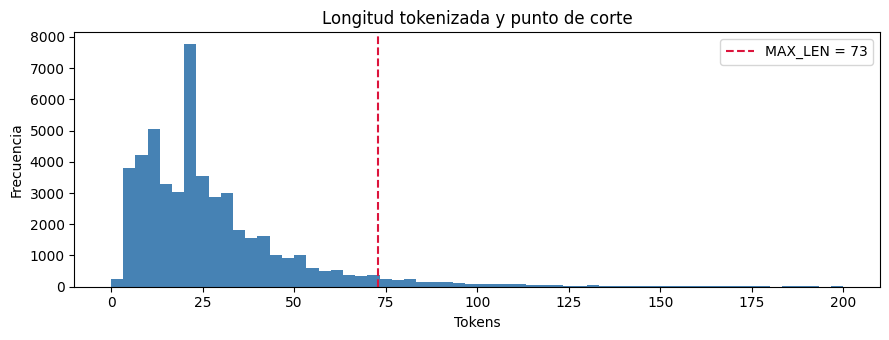

In [20]:
PAD, UNK = '<pad>', '<unk>'
PAD_IDX, UNK_IDX = 0, 1
FREC_MINIMA = 2

tokens_train = [tokenizar(t) for t in train_df['text']]

contador = Counter()
for tokens in tokens_train:
    contador.update(tokens)

vocabulario = {PAD: PAD_IDX, UNK: UNK_IDX}
for palabra, frecuencia in contador.most_common():
    if frecuencia >= FREC_MINIMA:
        vocabulario[palabra] = len(vocabulario)

longitudes = np.array([len(t) for t in tokens_train])
MAX_LEN = int(np.ceil(np.percentile(longitudes, 95)))

truncadas = (longitudes > MAX_LEN).mean()
tokens_val = [tokenizar(t) for t in val_df['text']]
oov = np.mean([np.mean([w not in vocabulario for w in t]) if t else 0 for t in tokens_val])

print(f'Tamaño del vocabulario: {len(vocabulario)}')
print(f'MAX_LEN (percentil 95): {MAX_LEN}')
print(f'Reseñas truncadas: {truncadas:.1%}')
print(f'Tasa media de palabras fuera de vocabulario en validación: {oov:.2%}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(longitudes, bins=60, range=(0, 200), color='steelblue')
ax.axvline(MAX_LEN, color='crimson', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
ax.set_title('Longitud tokenizada y punto de corte')
ax.set_xlabel('Tokens')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
def texto_a_ids(texto, max_len=None):
    max_len = max_len or MAX_LEN
    ids = [vocabulario.get(w, UNK_IDX) for w in tokenizar(texto)[:max_len]]
    return ids + [PAD_IDX] * (max_len - len(ids))


class ResenasDataset(Dataset):
    # Tokenizo al construir y no en cada acceso: repetir la tokenización en cada época
    # dominaba el tiempo de entrenamiento frente al cálculo en la GPU.
    def __init__(self, df, max_len=None):
        max_len = max_len or MAX_LEN
        self.input_ids = torch.tensor(
            [texto_a_ids(t, max_len) for t in df['text']], dtype=torch.long
        )
        self.etiquetas = torch.tensor((df['estrellas'] - 1).to_numpy(), dtype=torch.long)

    def __len__(self):
        return len(self.etiquetas)

    def __getitem__(self, i):
        return {'input_ids': self.input_ids[i], 'label': self.etiquetas[i]}


BATCH = 128
EN_GPU = torch.cuda.is_available()

inicio = time.time()
ds_train = ResenasDataset(train_df)
ds_val = ResenasDataset(val_df)
ds_test = ResenasDataset(test_df)
print(f'Tokenización previa de las tres particiones: {time.time() - inicio:.1f} s')

# Con los datos ya en memoria, los procesos de carga solo añadirían sobrecarga.
train_loader = DataLoader(ds_train, batch_size=BATCH, shuffle=True, generator=GENERADOR,
                          num_workers=0, pin_memory=EN_GPU)
val_loader = DataLoader(ds_val, batch_size=BATCH, num_workers=0, pin_memory=EN_GPU)
test_loader = DataLoader(ds_test, batch_size=BATCH, num_workers=0, pin_memory=EN_GPU)

lote = next(iter(train_loader))
print('Forma del lote de entrada:', lote['input_ids'].shape)
print('Forma de las etiquetas:   ', lote['label'].shape)
print(f'Lotes por época: {len(train_loader)} (entrenamiento), {len(val_loader)} (validación)')
print(f'Memoria de las secuencias: {ds_train.input_ids.element_size() * ds_train.input_ids.nelement() / 1e6:.0f} MB')

Tokenización previa de las tres particiones: 1.3 s
Forma del lote de entrada: torch.Size([128, 73])
Forma de las etiquetas:    torch.Size([128])
Lotes por época: 391 (entrenamiento), 40 (validación)
Memoria de las secuencias: 29 MB


---
## 10. Las arquitecturas

En vez de una clase por arquitectura, definimos un **codificador configurable**. Todas las variantes comparten el mismo esqueleto (embedding, red recurrente, representación final) y se diferencian en tres interruptores: el tipo de celda, si lee en una o dos direcciones, y si resume la secuencia con el último estado o con atención. Así lo único que cambia entre experimentos es lo que queremos medir.

Usamos `embedding_dim = 300` en todas las variantes, incluso en las que aprenden los embeddings desde cero, porque los vectores preentrenados tienen 300 dimensiones y otra elección mezclaría dos efectos distintos en la comparación final.

### Sobre la atención

Una LSTM convencional comprime toda la reseña en su último estado oculto, de modo que un único vector carga con decenas de palabras y el final de la secuencia pesa más que el principio. La atención aditiva calcula una puntuación para **cada** posición y construye la representación como una media ponderada de todos los estados.

Esos pesos son inspeccionables, lo que permite ver en qué palabras se apoyó el modelo para decidir.

In [22]:
class AtencionAditiva(nn.Module):
    def __init__(self, dim_entrada, dim_atencion=64):
        super().__init__()
        self.proyeccion = nn.Linear(dim_entrada, dim_atencion)
        self.puntuacion = nn.Linear(dim_atencion, 1, bias=False)

    def forward(self, estados, mascara):
        puntajes = self.puntuacion(torch.tanh(self.proyeccion(estados))).squeeze(-1)
        puntajes = puntajes.masked_fill(~mascara, torch.finfo(puntajes.dtype).min)
        pesos = torch.softmax(puntajes, dim=1)
        contexto = torch.bmm(pesos.unsqueeze(1), estados).squeeze(1)
        return contexto, pesos


class CodificadorSecuencial(nn.Module):
    def __init__(self, tam_vocabulario, dim_embedding=300, dim_oculta=128, celda='lstm',
                 bidireccional=False, con_atencion=False, dropout=0.3,
                 pesos_preentrenados=None, congelar=False):
        super().__init__()
        self.con_atencion = con_atencion

        if pesos_preentrenados is not None:
            # La dimensión la impone la matriz preentrenada, no el argumento.
            dim_embedding = pesos_preentrenados.shape[1]
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(pesos_preentrenados, dtype=torch.float),
                freeze=congelar, padding_idx=PAD_IDX,
            )
        else:
            self.embedding = nn.Embedding(tam_vocabulario, dim_embedding, padding_idx=PAD_IDX)

        capa = nn.LSTM if celda == 'lstm' else nn.GRU
        self.celda = celda
        self.rnn = capa(dim_embedding, dim_oculta, batch_first=True, bidirectional=bidireccional)

        self.dim_salida = dim_oculta * (2 if bidireccional else 1)
        self.atencion = AtencionAditiva(self.dim_salida) if con_atencion else None
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        mascara = input_ids != PAD_IDX
        salidas, estado = self.rnn(self.embedding(input_ids))
        oculto = estado[0] if self.celda == 'lstm' else estado

        if self.atencion is not None:
            representacion, pesos = self.atencion(salidas, mascara)
        else:
            if self.rnn.bidirectional:
                representacion = torch.cat((oculto[-2], oculto[-1]), dim=1)
            else:
                representacion = oculto[-1]
            pesos = None

        return self.dropout(representacion), pesos

---
## 11. El entrenamiento

Envolvemos el codificador en un módulo de Lightning. Vamos a entrenar seis modelos y encapsular el bucle garantiza que todos compartan exactamente el mismo procedimiento.

La parada temprana vigila el **F1-macro de validación** y no la pérdida, porque es la métrica con la que decidimos, y guardamos el mejor punto de control para restaurarlo al terminar. Sin eso evaluaríamos el modelo de la última época, que no tiene por qué ser el mejor.

### Por qué resembramos el generador en cada experimento

Fijar la semilla global antes de cada entrenamiento no basta. El generador del `DataLoader` mantiene **su propio estado interno**, que avanza al consumir los lotes, así que el segundo modelo empezaría a barajar desde donde lo dejó el primero. Cada arquitectura vería los ejemplos en un orden distinto y parte de la diferencia sería atribuible al barajado.

Como las diferencias esperadas entre celdas recurrentes son pequeñas, esa variación podría enmascararlas. Resembrarlo dentro de la función de entrenamiento garantiza que los seis modelos vean los mismos lotes en el mismo orden.

In [23]:
class ClasificadorResenas(pl.LightningModule):
    def __init__(self, codificador, dim_entrada, num_clases=5, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['codificador'])
        self.codificador = codificador
        self.salida = nn.Linear(dim_entrada, num_clases)
        self.criterio = nn.CrossEntropyLoss()
        self.f1_val = torchmetrics.F1Score(task='multiclass', num_classes=num_clases, average='macro')
        self.acc_val = torchmetrics.Accuracy(task='multiclass', num_classes=num_clases)

    def forward(self, input_ids):
        representacion, pesos = self.codificador(input_ids)
        return self.salida(representacion), pesos

    def _paso(self, lote):
        logits, _ = self(lote['input_ids'])
        return logits, self.criterio(logits, lote['label'])

    def training_step(self, lote, idx):
        _, perdida = self._paso(lote)
        self.log('train_loss', perdida, on_step=False, on_epoch=True, prog_bar=True)
        return perdida

    def validation_step(self, lote, idx):
        logits, perdida = self._paso(lote)
        self.f1_val(logits, lote['label'])
        self.acc_val(logits, lote['label'])
        self.log('val_loss', perdida, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.f1_val, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.acc_val, on_epoch=True, prog_bar=False)
        return perdida

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-5)

In [24]:
MAX_EPOCAS = 12
PACIENCIA = 3


def entrenar(nombre, codificador, lr=1e-3):
    pl.seed_everything(SEED, workers=True)
    # El generador del DataLoader guarda su propio estado: sin resembrarlo, cada modelo
    # vería los lotes en un orden distinto y la comparación dejaría de ser controlada.
    GENERADOR.manual_seed(SEED)

    modelo = ClasificadorResenas(codificador, codificador.dim_salida, num_clases=NUM_CLASES, lr=lr)
    punto_control = ModelCheckpoint(monitor='val_f1', mode='max', save_top_k=1)
    parada = EarlyStopping(monitor='val_f1', mode='max', patience=PACIENCIA)

    registros = [CSVLogger('csv_logs', name=nombre)]
    if HAY_TENSORBOARD:
        registros.append(TensorBoardLogger('tb_logs', name=nombre))

    entrenador = pl.Trainer(
        max_epochs=MAX_EPOCAS,
        accelerator='auto',
        devices=1,
        logger=registros,
        callbacks=[punto_control, parada],
        enable_model_summary=False,
        log_every_n_steps=25,
    )

    inicio = time.time()
    entrenador.fit(modelo, train_loader, val_loader)
    segundos = time.time() - inicio

    # weights_only=False porque el punto de control de Lightning guarda algo más que tensores.
    estado = torch.load(punto_control.best_model_path, map_location='cpu',
                        weights_only=False)['state_dict']
    modelo.load_state_dict(estado)

    return modelo.to(DEVICE).eval(), segundos, entrenador, punto_control.best_model_score


@torch.no_grad()
def predecir(modelo, cargador):
    modelo.eval().to(DEVICE)
    reales, predichas, probabilidades = [], [], []
    for lote in cargador:
        logits, _ = modelo(lote['input_ids'].to(DEVICE))
        probs = torch.softmax(logits, dim=1)
        reales.extend((lote['label'] + 1).tolist())
        predichas.extend((probs.argmax(dim=1).cpu() + 1).tolist())
        probabilidades.extend(probs.cpu().numpy())
    return np.array(reales), np.array(predichas), np.array(probabilidades)

---
## 12. Comparación de arquitecturas recurrentes

Entrenamos cuatro variantes con la misma dimensión de embedding, el mismo vocabulario, el mismo corte de longitud y el mismo procedimiento:

| Variante | Celda | Dirección | Resumen de la secuencia |
|---|---|---|---|
| LSTM | LSTM | una | último estado oculto |
| BiLSTM | LSTM | dos | concatenación de ambos extremos |
| GRU | GRU | una | último estado oculto |
| LSTM + atención | LSTM | una | media ponderada por atención |

Incluimos la GRU porque tiene tres puertas en lugar de cuatro y por tanto menos parámetros: queremos comprobar si la maquinaria adicional de la LSTM se justifica con datos abundantes.

In [25]:
CONFIGURACIONES = [
    {'nombre': 'LSTM', 'celda': 'lstm', 'bidireccional': False, 'con_atencion': False},
    {'nombre': 'BiLSTM', 'celda': 'lstm', 'bidireccional': True, 'con_atencion': False},
    {'nombre': 'GRU', 'celda': 'gru', 'bidireccional': False, 'con_atencion': False},
    {'nombre': 'LSTM + atención', 'celda': 'lstm', 'bidireccional': False, 'con_atencion': True},
]

modelos = {}

for config in CONFIGURACIONES:
    nombre = config['nombre']
    print('\n' + '=' * 70)
    print(nombre)
    print('=' * 70)

    codificador = CodificadorSecuencial(
        tam_vocabulario=len(vocabulario),
        celda=config['celda'],
        bidireccional=config['bidireccional'],
        con_atencion=config['con_atencion'],
    )
    parametros = sum(p.numel() for p in codificador.parameters())

    modelo, segundos, _, _ = entrenar(nombre, codificador)
    reales, predichas, _ = predecir(modelo, val_loader)

    modelos[nombre] = modelo
    fila = evaluar(nombre, reales, predichas, segundos)
    fila['parámetros'] = parametros
    resultados_val.append(fila)

    print(f"F1-macro {fila['f1_macro']:.3f} | MAE {fila['mae_estrellas']:.3f} | "
          f"QWK {fila['qwk']:.3f} | {segundos:.0f} s | {parametros:,} parámetros")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



LSTM


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

F1-macro 0.499 | MAE 0.634 | QWK 0.756 | 49 s | 6,305,620 parámetros

GRU


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

F1-macro 0.505 | MAE 0.619 | QWK 0.769 | 46 s | 6,030,420 parámetros

LSTM + atención


F1-macro 0.501 | MAE 0.634 | QWK 0.759 | 42 s | 6,093,780 parámetros


In [26]:
pd.DataFrame(resultados_val).sort_values('f1_macro', ascending=False).round(4)

,modelo,accuracy,f1_macro,mae_estrellas,qwk,segundos,parámetros
0,TF-IDF + LogReg,0.5099,0.5072,0.6360,0.7484,17.4071,NaN
3,GRU,0.5033,0.5045,0.6186,0.7693,46.2727,6030420.0
4,LSTM + atención,0.5053,0.5010,0.6340,0.7592,41.7473,6093780.0
2,BiLSTM,0.4995,0.4994,0.6338,0.7560,48.9494,6305620.0
1,LSTM,0.3013,0.1904,1.4739,0.3385,58.4751,6085460.0


### Lo que muestran estos cuatro entrenamientos

Tres de las cuatro arquitecturas quedan muy juntas: la GRU alcanza 0,5045 de F1, la LSTM con atención 0,5010 y la BiLSTM 0,4994. Cinco milésimas separan a la mejor de la peor, con tiempos de entrenamiento parecidos y un número de parámetros del mismo orden. **Ninguna de las tres es claramente superior.**

El F1 esconde un matiz que sí importa: la GRU tiene el mejor MAE (0,6186 frente a 0,6338 y 0,6340) y el mejor QWK (0,7693). No acierta más veces que las otras, pero **cuando falla se equivoca más cerca**.

Además lo consigue con **menos parámetros que la BiLSTM** (6,03 millones frente a 6,31) y en menos tiempo. La BiLSTM, que duplica el coste de la capa recurrente para leer también de derecha a izquierda, termina siendo la peor de las tres.

### El caso de la LSTM

La LSTM simple se queda en **0,1904 de F1 con un MAE de 1,4739**. En F1 no llega ni al piso del azar (0,2029), aunque en MAE sí lo mejora (1,5862): predice casi siempre una franja central, lo que acorta la distancia media al valor real sin acertar la clase.

No es un fallo del código: comparte con las demás el vocabulario, los lotes en el mismo orden, la semilla y la rutina de entrenamiento. Lo único que cambia es el tipo de celda.

Las curvas de la sección siguiente muestran qué ocurrió.

---
## 13. Evolución del entrenamiento

Lightning registra las métricas en un fichero CSV y en TensorBoard cuando está disponible. Dibujamos las curvas con matplotlib a partir del CSV, porque TensorBoard depende de un servidor que no siempre se restaura al reabrir el cuaderno.

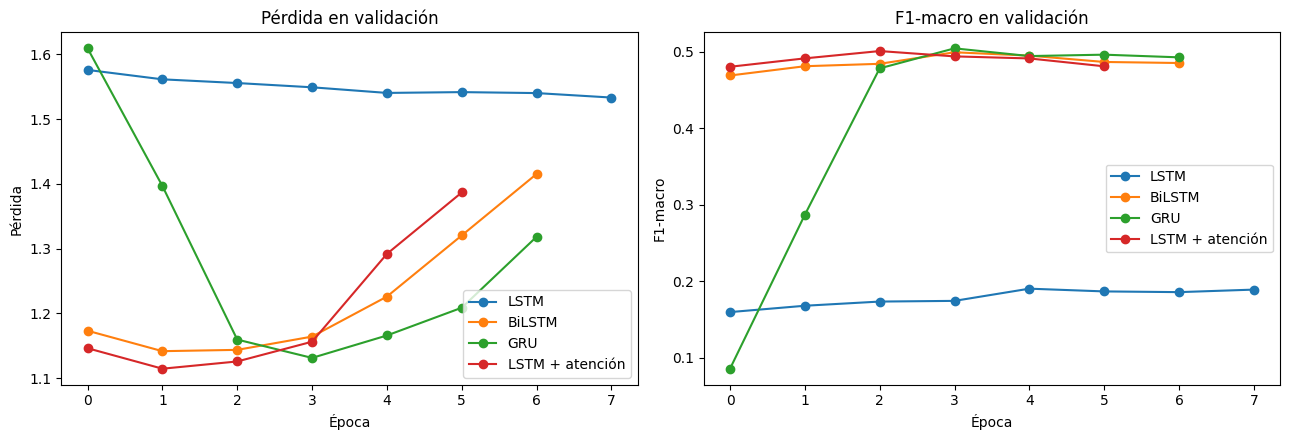

In [27]:
def leer_metricas(nombre):
    directorio = Path('csv_logs') / nombre
    if not directorio.exists():
        return None
    versiones = sorted(directorio.glob('version_*'))
    if not versiones:
        return None
    csv = versiones[-1] / 'metrics.csv'
    return pd.read_csv(csv) if csv.exists() else None


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for nombre in modelos:
    metricas = leer_metricas(nombre)
    if metricas is None or 'val_loss' not in metricas.columns:
        continue
    perdida = metricas.dropna(subset=['val_loss'])
    f1 = metricas.dropna(subset=['val_f1'])
    axes[0].plot(perdida['epoch'], perdida['val_loss'], marker='o', label=nombre)
    axes[1].plot(f1['epoch'], f1['val_f1'], marker='o', label=nombre)

axes[0].set_title('Pérdida en validación')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()
axes[1].set_title('F1-macro en validación')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('F1-macro')
axes[1].legend()
plt.tight_layout()
plt.show()

Las curvas explican el fracaso de la LSTM simple: **su pérdida de validación apenas se mueve, de 1,575 a 1,532 en ocho épocas**, y su F1 se queda entre 0,16 y 0,19. La BiLSTM y la de atención bajan por debajo de 1,20 desde la primera época y superan el 0,47 de F1. No es sobreajuste ni falta de datos: no llegó a aprender.

Las tres que sí entrenan tocan su mínimo de pérdida pronto —la BiLSTM y la de atención en la época 1, la GRU en la 3— y a partir de ahí la pérdida sube (la BiLSTM hasta 1,415 y la de atención hasta 1,387) mientras el F1 se mantiene plano en torno a 0,49. Esa divergencia entre una pérdida que empeora y un F1 que no mejora es el sobreajuste, y la parada temprana, que vigila el F1, detiene cada entrenamiento unas épocas después.

La GRU parte del peor punto de las cuatro, con 1,61 de pérdida y 0,086 de F1 en la primera época, y aun así termina con el mejor valor de validación, 0,505 en la época 3.

Mantenemos la LSTM fallida en la comparación porque el contraste con la GRU, con misma semilla, mismos datos y mismo procedimiento, muestra que el problema estuvo en el entrenamiento y no en los datos.

In [28]:
if not HAY_TENSORBOARD:
    print('TensorBoard no está instalado en este entorno; las curvas de arriba ya recogen la misma información.')
else:
    get_ipython().run_line_magic('load_ext', 'tensorboard')
    get_ipython().run_line_magic('tensorboard', '--logdir tb_logs/')

<IPython.core.display.Javascript object>

---
## 14. Tercer nivel: reutilizar vectores preentrenados

Hasta ahora los embeddings se han aprendido desde cero con cincuenta mil reseñas. Los vectores de spaCy se estimaron sobre un corpus de español mucho mayor, así que traen información sobre palabras que aquí aparecen pocas veces.

Antes de usarlos comprobamos **qué proporción del vocabulario tiene vector**, porque las reseñas están llenas de erratas y escritura descuidada que no aparece en un corpus general.

In [29]:
DIM_EMB = nlp.vocab.vectors.shape[1]
matriz_embeddings = np.zeros((len(vocabulario), DIM_EMB), dtype=np.float32)

sin_vector = []
con_vector = 0
for palabra, indice in vocabulario.items():
    if palabra in (PAD, UNK):
        continue
    lexema = nlp.vocab[palabra]
    if lexema.has_vector and np.any(lexema.vector):
        matriz_embeddings[indice] = lexema.vector
        con_vector += 1
    else:
        sin_vector.append(palabra)

cobertura = con_vector / (len(vocabulario) - 2)
print(f'Dimensión de los vectores: {DIM_EMB}')
print(f'Cobertura del vocabulario: {cobertura:.1%} ({con_vector} de {len(vocabulario) - 2})')
print(f'\nEjemplos de palabras sin vector: {sin_vector[:25]}')

Dimensión de los vectores: 300
Cobertura del vocabulario: 97.1% (18975 de 19549)

Ejemplos de palabras sin vector: ['amazón', '4g', 'airpods', 'plasticoso', 'descambiarlo', 'envalado', 'spigen', '3mm', '1mm', 'celeritas', 'osmo', 'plasticucho', '3m', 'descambiado', 'dyson', 'rayajos', '2mm', 'olgura', 'tourline', 'devolvere', '80w', 'rayazos', 'descoserse', '5mm', '1m']


La cobertura es del **97,1%**: de los 19.549 términos del vocabulario, 18.975 tienen vector preentrenado. Lo que ocurra después no podrá achacarse a falta de cobertura.

Las 574 palabras que quedan fuera son marcas (*airpods*, *spigen*, *dyson*, *tourline*), unidades técnicas (*4g*, *3mm*, *80w*), erratas (*amazón*, *olgura*, *devolvere*) y formaciones coloquiales como *plasticoso*, *plasticucho*, *rayajos* o *descambiarlo*. Es vocabulario propio del dominio.

### Qué arquitectura llevamos a este nivel

Elegimos la **GRU**. Las tres que convergieron quedaron muy juntas en F1 (0,5045, 0,5010 y 0,4994), pero la GRU fue la mejor en las dos métricas ordinales, con 0,6186 de MAE y 0,7693 de QWK, y la más económica en parámetros. Usar la misma arquitectura en ambos casos permite atribuir cualquier diferencia a los embeddings.

Entrenamos dos variantes que solo se diferencian en el parámetro `congelar`: ¿conviene conservar intacto el conocimiento general del español, o dejar que la red lo especialice en el lenguaje de las reseñas?

Recordamos lo visto en la sección 6.7: estos vectores sitúan *bueno* y *malo* a 0,758 de similitud.

In [30]:
# Llevo a este nivel la GRU, que fue la de mejor MAE y QWK entre las cuatro arquitecturas.
MEJOR_ARQUITECTURA = 'GRU'
config_mejor = next(c for c in CONFIGURACIONES if c['nombre'] == MEJOR_ARQUITECTURA)

for congelar in (True, False):
    sufijo = 'congelados' if congelar else 'ajustables'
    etiqueta = f'{MEJOR_ARQUITECTURA} + vectores {sufijo}'
    print('\n' + '=' * 70)
    print(etiqueta)
    print('=' * 70)

    codificador = CodificadorSecuencial(
        tam_vocabulario=len(vocabulario),
        celda=config_mejor['celda'],
        bidireccional=config_mejor['bidireccional'],
        con_atencion=config_mejor['con_atencion'],
        pesos_preentrenados=matriz_embeddings,
        congelar=congelar,
    )

    modelo, segundos, _, _ = entrenar(etiqueta, codificador)
    reales, predichas, _ = predecir(modelo, val_loader)

    modelos[etiqueta] = modelo
    fila = evaluar(etiqueta, reales, predichas, segundos)
    fila['parámetros'] = sum(p.numel() for p in codificador.parameters())
    resultados_val.append(fila)

    print(f"F1-macro {fila['f1_macro']:.3f} | MAE {fila['mae_estrellas']:.3f} | "
          f"QWK {fila['qwk']:.3f} | {segundos:.0f} s")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42



GRU + vectores congelados


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: `Trainer.fit` stopped: `max_epochs=12` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=12` reached.


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

F1-macro 0.488 | MAE 0.640 | QWK 0.763 | 80 s

GRU + vectores ajustables


F1-macro 0.485 | MAE 0.648 | QWK 0.755 | 67 s


### Los vectores preentrenados empeoran el resultado

Las dos variantes quedan por debajo de la GRU con embeddings desde cero: 0,4875 con los vectores congelados y 0,4846 dejándolos ajustar, frente a 0,5045. La caída viene acompañada de un MAE peor (0,6396 y 0,6476 frente a 0,6186) y de más tiempo de entrenamiento.

**No es un problema de cobertura**, que es del 97,1%. La explicación más plausible es la de la sección 6.7: estos vectores colocan *bueno* y *malo* a 0,758 de similitud y *caro* y *barato* a 0,787. Para una tarea temática funcionarían bien; para una de **polaridad**, la red tendría que reorganizar una geometría que no le sirve en lugar de construir una nueva.

Que la variante ajustable tampoco recupere el terreno encaja con esa idea: doce épocas quizá no basten para reorganizar un espacio de 300 dimensiones.

**El preentrenamiento no es automáticamente beneficioso**: depende de si el espacio de origen codifica la propiedad que la tarea necesita. Con 50.000 ejemplos etiquetados hay señal suficiente para aprender embeddings del propio dominio.

---
## 15. Comparación de los tres niveles

Reunimos todo en una tabla y añadimos el desempeño frente al tiempo de entrenamiento.

Los tiempos **no son directamente comparables**: el modelo lineal se entrena con scikit-learn sobre CPU y las redes sobre GPU, así que el eje horizontal mezcla dos tipos de cómputo. La comparación de coste es válida entre las redes; frente al baseline solo sirve como orden de magnitud.

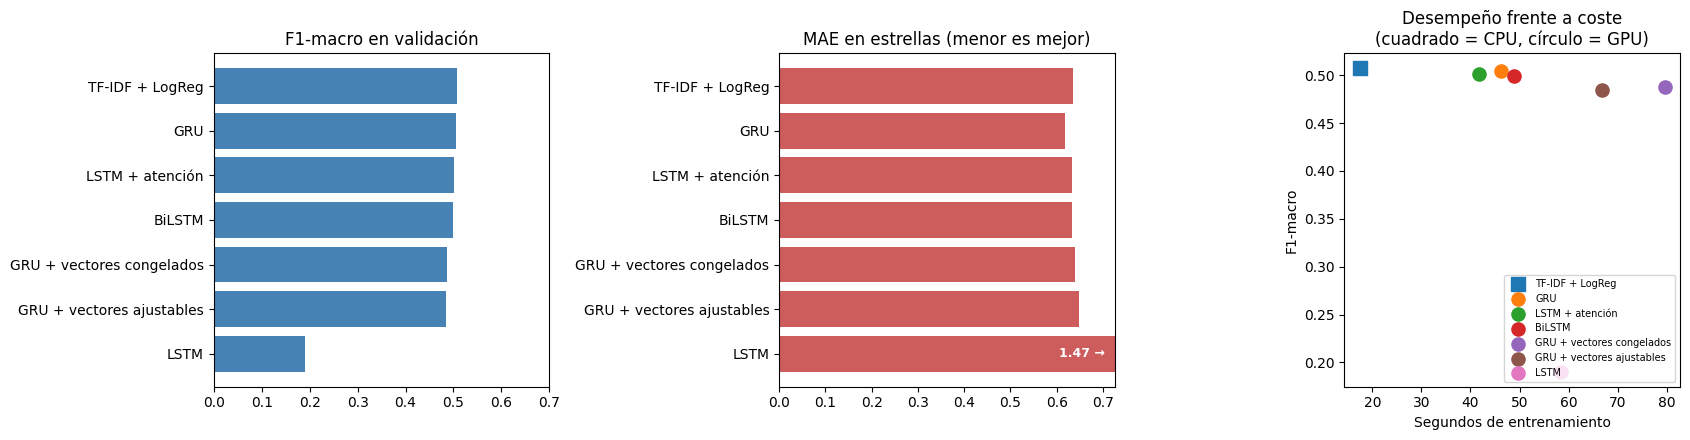

,modelo,accuracy,f1_macro,mae_estrellas,qwk,segundos,parámetros
0,TF-IDF + LogReg,0.5099,0.5072,0.6360,0.7484,17.4071,NaN
1,GRU,0.5033,0.5045,0.6186,0.7693,46.2727,6030420.0
2,LSTM + atención,0.5053,0.5010,0.6340,0.7592,41.7473,6093780.0
3,BiLSTM,0.4995,0.4994,0.6338,0.7560,48.9494,6305620.0
4,GRU + vectores congelados,0.4883,0.4875,0.6396,0.7631,79.5880,6030420.0
5,GRU + vectores ajustables,0.4819,0.4846,0.6476,0.7555,66.7414,6030420.0
6,LSTM,0.3013,0.1904,1.4739,0.3385,58.4751,6085460.0


In [31]:
tabla = pd.DataFrame(resultados_val).sort_values('f1_macro', ascending=False).reset_index(drop=True)
orden = tabla.sort_values('f1_macro')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].barh(orden['modelo'], orden['f1_macro'], color='steelblue')
axes[0].set_title('F1-macro en validación')
axes[0].set_xlim(0, max(0.7, orden['f1_macro'].max() * 1.15))

# Un modelo que no converge saca de escala al resto: acoto el eje y anoto su valor real.
axes[1].barh(orden['modelo'], orden['mae_estrellas'], color='indianred')
limite = orden['mae_estrellas'].nsmallest(len(orden) - 1).max() * 1.12
axes[1].set_xlim(0, limite)
for posicion, valor in enumerate(orden['mae_estrellas']):
    if valor > limite:
        axes[1].text(limite * 0.97, posicion, f'{valor:.2f} →', ha='right', va='center',
                     fontsize=9, color='white', weight='bold')
axes[1].set_title('MAE en estrellas (menor es mejor)')

for _, fila in tabla.iterrows():
    if pd.isna(fila['segundos']):
        continue
    # El baseline corre en CPU con scikit-learn y las redes en GPU: los tiempos no son comparables.
    es_baseline = fila['modelo'] == 'TF-IDF + LogReg'
    axes[2].scatter(fila['segundos'], fila['f1_macro'], s=90,
                    marker='s' if es_baseline else 'o', label=fila['modelo'])
axes[2].set_title('Desempeño frente a coste\n(cuadrado = CPU, círculo = GPU)')
axes[2].set_xlabel('Segundos de entrenamiento')
axes[2].set_ylabel('F1-macro')
axes[2].legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

tabla.round(4)

### La respuesta a la pregunta de investigación

El mejor representante de cada nivel:

| Nivel | Mejor modelo | F1-macro | MAE | QWK |
|---|---|---:|---:|---:|
| Sin orden (bolsa de palabras) | TF-IDF + LogReg | **0,5072** | 0,6360 | 0,7484 |
| Con orden (embeddings desde cero) | GRU | 0,5045 | **0,6186** | **0,7693** |
| Con vectores preentrenados | GRU + vectores congelados | 0,4875 | 0,6396 | 0,7631 |

Solo con el F1-macro, la conclusión sería negativa para las redes: el modelo lineal alcanza 0,5072 y la mejor red recurrente 0,5045, con casi el triple de tiempo de entrenamiento y seis millones de parámetros frente a una regresión logística.

Pero las dos métricas que **tienen en cuenta el orden de las clases** se decantan por la red: la GRU reduce el MAE en 0,017 estrellas y mejora el QWK en 0,021. El QWK gana casi ocho veces más de lo que el F1 pierde.

Nuestra lectura: **el orden de las palabras no ayuda a acertar más veces, pero sí a equivocarse por menos margen**. Ambos modelos aciertan la nota exacta en torno a la mitad de los casos, y la diferencia está en que la red tiende a quedarse en la casilla de al lado. Encaja con el análisis exploratorio: entender un *pero* no sirve para distinguir cuatro estrellas de cinco, que es una frontera subjetiva, pero sí para no confundir una reseña tibia con una indignada.

**Con Accuracy y F1 como únicas métricas habríamos concluido que las redes recurrentes no aportan nada aquí.** La diferencia es pequeña, pero solo se ve midiendo la severidad del error y no únicamente su frecuencia.

Sobre el coste: ganar 0,017 estrellas de MAE a cambio de triplicar el tiempo de entrenamiento y complicar el despliegue es discutible en producción. El modelo lineal sigue siendo una opción razonable.

---
## 16. Selección del modelo final

La tabla anterior no da un ganador obvio, así que revisamos los candidatos.

El **TF-IDF queda descartado**, es el peor en MAE y QWK de los tres primeros.

Las **dos variantes con vectores preentrenados** quedan fuera: 0,4875 y 0,4846 de F1 frente a 0,5045, y peor MAE.

La **LSTM simple** no entra en la comparación: con 0,1904 de F1 no llegó a converger.

Quedan tres candidatos muy juntos:

| Modelo | F1-macro | MAE | QWK |
|---|---:|---:|---:|
| GRU | 0,5045 | **0,6186** | **0,7693** |
| LSTM + atención | 0,5010 | 0,6340 | 0,7592 |
| BiLSTM | 0,4994 | 0,6338 | 0,7560 |

Los separan cinco milésimas de F1, diferencia que no consideramos significativa con una sola semilla. Pero en MAE y QWK la GRU gana de forma consistente y un kappa un punto por encima del siguiente.

**Elegimos la GRU**, por coherencia con el criterio fijado al escoger las métricas: en un problema ordinal preferimos el modelo que se equivoca cerca antes que el que acierta un poco más a menudo.

In [32]:
MEJOR_MODELO = 'GRU'
modelo_final = modelos[MEJOR_MODELO]

print('Modelo seleccionado:', MEJOR_MODELO)

Modelo seleccionado: GRU


---
## 17. Evaluación final sobre la partición de prueba

In [33]:
y_real, y_pred, y_probs = predecir(modelo_final, test_loader)
metricas_test = evaluar(MEJOR_MODELO, y_real, y_pred)

print('RESULTADO EN PRUEBA -', MEJOR_MODELO)
print('-' * 60)
for clave in ['accuracy', 'f1_macro', 'mae_estrellas', 'qwk']:
    print(f'{clave:15s} {metricas_test[clave]:.4f}')

print('\nDetalle por calificación:\n')
print(classification_report(y_real, y_pred, labels=CLASES,
                            target_names=[f'{c} estrellas' for c in CLASES],
                            digits=4, zero_division=0))

RESULTADO EN PRUEBA - GRU
------------------------------------------------------------
accuracy        0.5050
f1_macro        0.5066
mae_estrellas   0.6037
qwk             0.7798

Detalle por calificación:

              precision    recall  f1-score   support

 1 estrellas     0.6702    0.6260    0.6474      1000
 2 estrellas     0.4066    0.4905    0.4446       999
 3 estrellas     0.4090    0.4020    0.4054      1000
 4 estrellas     0.4480    0.4054    0.4256       999
 5 estrellas     0.6188    0.6014    0.6100       996

    accuracy                         0.5050      4994
   macro avg     0.5105    0.5051    0.5066      4994
weighted avg     0.5105    0.5050    0.5066      4994



### Lectura del resultado final

El resultado en prueba es **ligeramente mejor** que en validación: 0,5066 de F1 frente a 0,5045, y un MAE de 0,6037 frente a 0,6186. Esperábamos lo contrario, porque la validación intervino en la selección. Que no ocurra indica que el modelo generaliza y que la diferencia cae dentro del ruido de muestreo de unos cinco mil ejemplos.

El desglose por clase:

| Calificación | F1 | Comportamiento |
|---|---:|---|
| 1 estrella | 0,6474 | la mejor resuelta |
| 2 estrellas | 0,4446 | recall alto (0,49), precisión baja (0,41) |
| 3 estrellas | 0,4054 | la más difícil |
| 4 estrellas | 0,4256 | recall bajo (0,41) |
| 5 estrellas | 0,6100 | segunda mejor |

**Los extremos se resuelven mejor que las clases intermedias**, con más de veinte puntos entre la mejor y la peor. Encaja con el índice de Jaccard: las clases 2, 3 y 4 comparten en torno al 70% de su vocabulario con sus vecinas, mientras 1 y 5 son las más distintas entre sí.

La clase de tres estrellas es la peor. Es la única con dos vecinas a ambos lados, y su vocabulario característico eran matizadores (*pero*, *algo*, *poco*, *aunque*) en lugar de palabras de valoración.

---
## 18. Dónde se equivoca el modelo

Si el solapamiento de vocabulario entre calificaciones vecinas era alto, el error debería concentrarse junto a la diagonal y casi no debería haber confusiones entre extremos opuestos.

Añadimos la distribución del error con signo, para ver si el modelo es sistemáticamente optimista o pesimista.

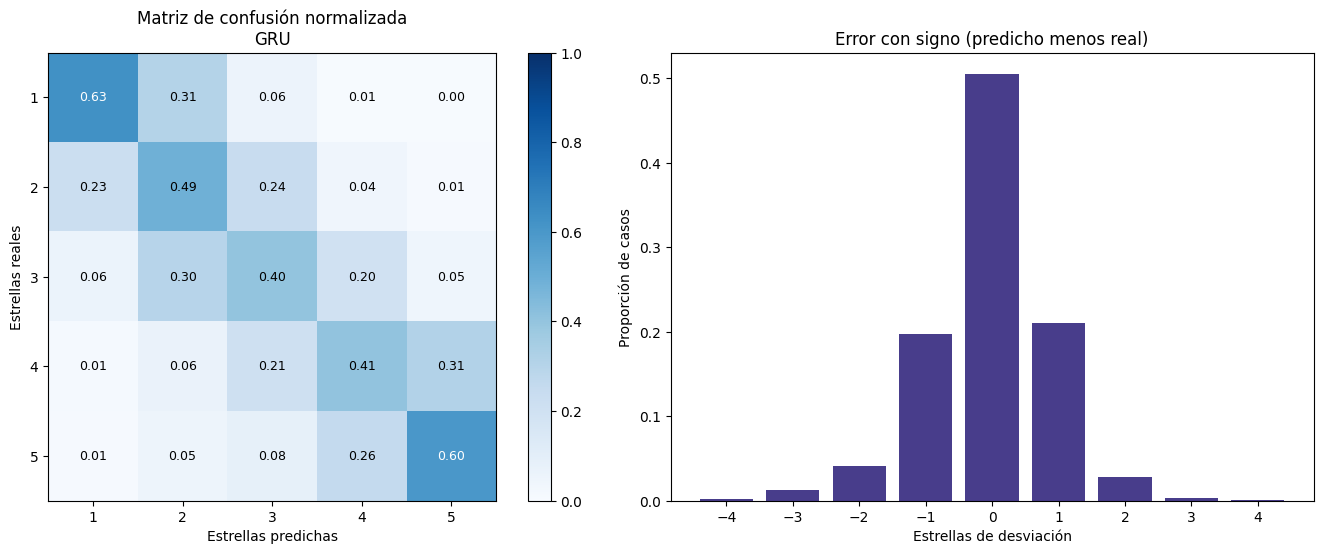

Aciertos exactos:                   50.5%
Dentro de una estrella de margen:   91.2%
Errores graves (2 o más estrellas): 8.8%
Sesgo medio del modelo:             -0.045 estrellas


In [34]:
matriz = confusion_matrix(y_real, y_pred, labels=CLASES)
matriz_norm = matriz / matriz.sum(axis=1, keepdims=True)
error_con_signo = y_pred - y_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

im = axes[0].imshow(matriz_norm, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(NUM_CLASES), CLASES)
axes[0].set_yticks(range(NUM_CLASES), CLASES)
axes[0].set_xlabel('Estrellas predichas')
axes[0].set_ylabel('Estrellas reales')
axes[0].set_title(f'Matriz de confusión normalizada\n{MEJOR_MODELO}')
for i in range(NUM_CLASES):
    for j in range(NUM_CLASES):
        axes[0].text(j, i, f'{matriz_norm[i, j]:.2f}', ha='center', va='center',
                     color='white' if matriz_norm[i, j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=axes[0])

valores, cuentas = np.unique(error_con_signo, return_counts=True)
axes[1].bar(valores, cuentas / cuentas.sum(), color='darkslateblue')
axes[1].set_title('Error con signo (predicho menos real)')
axes[1].set_xlabel('Estrellas de desviación')
axes[1].set_ylabel('Proporción de casos')
axes[1].set_xticks(valores)

plt.tight_layout()
plt.show()

exactos = (error_con_signo == 0).mean()
vecinos = (np.abs(error_con_signo) <= 1).mean()
graves = (np.abs(error_con_signo) >= 2).mean()

print(f'Aciertos exactos:                   {exactos:.1%}')
print(f'Dentro de una estrella de margen:   {vecinos:.1%}')
print(f'Errores graves (2 o más estrellas): {graves:.1%}')
print(f'Sesgo medio del modelo:             {error_con_signo.mean():+.3f} estrellas')

La matriz muestra el patrón que cabía esperar por el solapamiento de vocabulario.

**Casi toda la masa de error está junto a la diagonal.** La diagonal principal recorre 0,63 / 0,49 / 0,40 / 0,41 / 0,60. Las reseñas de una estrella se confunden con las de dos en un 31% de los casos, las de cuatro con las de cinco en un 31%, y las de tres se reparten entre dos (30%) y cuatro (20%).

**Las confusiones entre extremos opuestos son casi inexistentes: 0,00 y 0,01.** El modelo distingue bien de qué lado está la opinión; lo que no consigue es calibrar la intensidad.

Los tres números que resumen el comportamiento:

- **Acierto exacto: 50,5%**
- **Dentro de una estrella de margen: 91,2%**
- **Desviación de dos o más estrellas: 8,8%**

El 91,2% es la cifra más útil para juzgar si el sistema serviría en la práctica y no aparece en ninguna métrica estándar. Un modelo que sitúa nueve de cada diez reseñas a menos de una estrella de su valor real puede servir para ordenar opiniones, detectar incoherencias o priorizar revisiones.

El histograma de error con signo es **casi simétrico**, con un sesgo medio de −0,045 estrellas. El modelo no es optimista ni pesimista de forma sistemática, lo cual importa porque un sesgo constante distorsionaría cualquier agregado por producto.

### 19. Los errores en detalle

Miramos tres grupos: los errores graves, los cometidos con mucha confianza y los aciertos con poca.

In [35]:
analisis = test_df.copy()

# El cargador de prueba no baraja, así que las predicciones deben venir en el orden del dataframe.
assert (y_real == analisis['estrellas'].to_numpy()).all(), 'Las predicciones no están alineadas'

analisis['prediccion'] = y_pred
analisis['confianza'] = y_probs.max(axis=1)
analisis['desviacion'] = y_pred - analisis['estrellas']
analisis['acierto'] = analisis['desviacion'] == 0

graves_df = analisis[analisis['desviacion'].abs() >= 2].sort_values('confianza', ascending=False)

print(f'Errores graves: {len(graves_df)} de {len(analisis)}\n')
for _, fila in graves_df.head(4).iterrows():
    print(f"Real {fila['estrellas']} -> predicho {fila['prediccion']} "
          f"(confianza {fila['confianza']:.1%})")
    print('  ', fila['text'][:260].replace('\n', ' '))
    print()

Errores graves: 439 de 4994

Real 3 -> predicho 1 (confianza 92.6%)
   Mala calidad, solo funciona la mitad, nada recomendable

Real 3 -> predicho 1 (confianza 90.5%)
   Yo tengo un iPhone 8 normal No recuerdo haberla pedido para iPhone 8 Plus y lo que he recibido no me sirve

Real 3 -> predicho 1 (confianza 88.7%)
   He utilizado este producto solo el primer mes de lactancia. Despues al tener mas peso el bebe no es necesario.

Real 3 -> predicho 1 (confianza 87.0%)
   El producto no llegó en el tiempo indicado, exactamente 24 días después, es lamentable que pasen estas cosas, ya no me sirve el producto para la fecha en la que ha llegado.



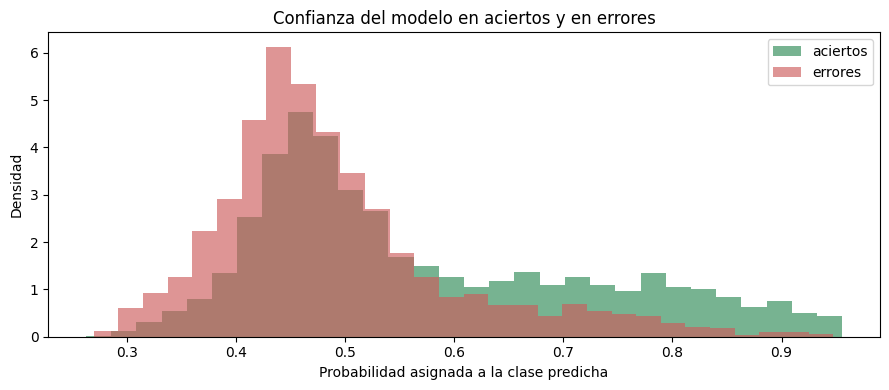

Confianza media en aciertos: 0.57
Confianza media en errores:  0.489


In [36]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(analisis.loc[analisis['acierto'], 'confianza'], bins=30, alpha=0.65,
        label='aciertos', color='seagreen', density=True)
ax.hist(analisis.loc[~analisis['acierto'], 'confianza'], bins=30, alpha=0.65,
        label='errores', color='indianred', density=True)
ax.set_title('Confianza del modelo en aciertos y en errores')
ax.set_xlabel('Probabilidad asignada a la clase predicha')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

print('Confianza media en aciertos:', round(analisis.loc[analisis['acierto'], 'confianza'].mean(), 3))
print('Confianza media en errores: ', round(analisis.loc[~analisis['acierto'], 'confianza'].mean(), 3))

### Los errores graves no siempre son errores del modelo

De las 4.994 reseñas de prueba, **439 se desvían dos o más estrellas**. Las cuatro que el modelo falló con mayor confianza son casos reales de tres estrellas clasificados como una:

> *"Mala calidad, solo funciona la mitad, nada recomendable"* — calificada con **3 estrellas**, predicha como 1 con un 92,6% de confianza.

> *"El producto no llegó en el tiempo indicado, exactamente 24 días después, es lamentable que pasen estas cosas, ya no me sirve el producto"* — calificada con **3 estrellas**, predicha como 1.

Cualquier lector situaría estos textos en el extremo negativo. Enlaza con la auditoría inicial: en este corpus el mismo texto puede aparecer con calificaciones distintas, porque la nota refleja el criterio personal de quien la puso.

Parte de ese 8,8% de errores graves no mide un fallo del modelo sino **ruido en la etiqueta**. No podemos cuantificar qué proporción, pero sitúa el techo real por debajo del 100% por razones ajenas a la arquitectura.

**La confianza es informativa**: 0,570 de media en los aciertos frente a 0,489 en los errores. La probabilidad de salida sirve como señal de fiabilidad y podría usarse como umbral para derivar a revisión humana las predicciones dudosas.

### 20. ¿Importa la longitud de la reseña?

Si las reseñas más largas rindieran peor, sería indicio de que el corte en el percentil 95 elimina información útil.

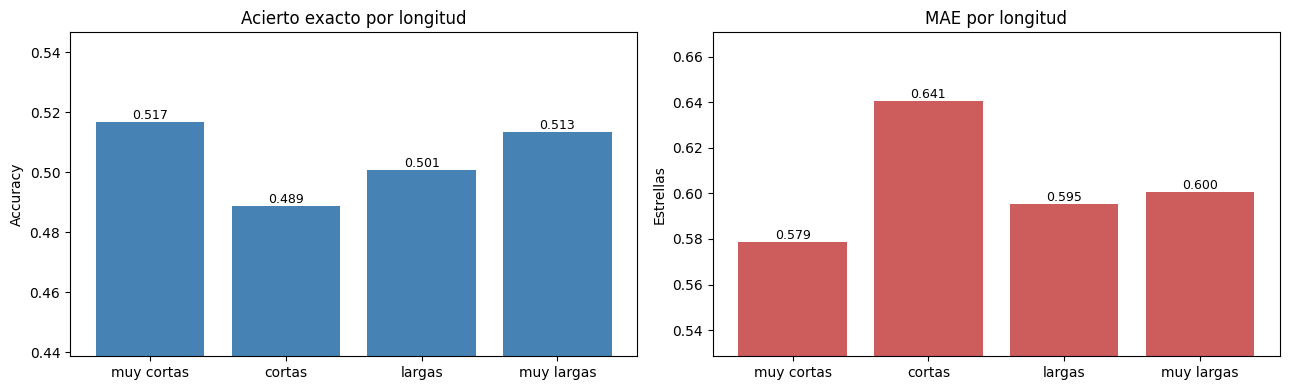

,casos,accuracy,mae,truncadas
tramo,,,,
muy cortas,1324,0.517,0.579,0.000
cortas,1269,0.489,0.641,0.000
largas,1152,0.501,0.595,0.000
muy largas,1249,0.513,0.600,0.181


In [37]:
analisis['n_tokens'] = [len(tokenizar(t)) for t in analisis['text']]
analisis['tramo'] = pd.qcut(analisis['n_tokens'], 4,
                            labels=['muy cortas', 'cortas', 'largas', 'muy largas'])

resumen_tramo = analisis.groupby('tramo', observed=True).agg(
    casos=('acierto', 'size'),
    accuracy=('acierto', 'mean'),
    mae=('desviacion', lambda s: s.abs().mean()),
    truncadas=('n_tokens', lambda s: (s > MAX_LEN).mean()),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
etiquetas = resumen_tramo.index.astype(str)

# Acoto los ejes: con origen en cero las diferencias entre tramos serían invisibles.
axes[0].bar(etiquetas, resumen_tramo['accuracy'], color='steelblue')
axes[0].set_ylim(resumen_tramo['accuracy'].min() - 0.05, resumen_tramo['accuracy'].max() + 0.03)
axes[0].set_title('Acierto exacto por longitud')
axes[0].set_ylabel('Accuracy')

axes[1].bar(etiquetas, resumen_tramo['mae'], color='indianred')
axes[1].set_ylim(resumen_tramo['mae'].min() - 0.05, resumen_tramo['mae'].max() + 0.03)
axes[1].set_title('MAE por longitud')
axes[1].set_ylabel('Estrellas')

for eje, columna in zip(axes, ['accuracy', 'mae']):
    for i, valor in enumerate(resumen_tramo[columna]):
        eje.text(i, valor, f'{valor:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

resumen_tramo.round(3)

La longitud **no influye prácticamente nada**. El acierto oscila entre 0,489 y 0,517 entre los cuatro tramos y el MAE entre 0,579 y 0,641, sin tendencia clara: las reseñas muy cortas obtienen el mejor resultado (0,517) y las muy largas el segundo (0,513).

En el tramo de las muy largas **el 18,1% de las reseñas sufre truncamiento**. Si cortar en 73 tokens destruyera información útil, ese grupo debería rendir peor, y no ocurre. Fijar `MAX_LEN` en el percentil 95 fue una decisión adecuada, y la información que determina la calificación está sobre todo al principio de la reseña.

Alargar las secuencias habría multiplicado el coste de cómputo sin ganancia apreciable.

---
## 21. Qué mira el modelo: visualización de la atención

Los pesos de atención indican cuánto contribuyó cada palabra a la representación final, así que permiten pasar de *el modelo se equivocó* a *el modelo se equivocó porque se fijó en estas palabras e ignoró aquellas*.

In [38]:
modelo_atencion = modelos.get('LSTM + atención')


@torch.no_grad()
def pesos_atencion(texto, modelo=None):
    modelo = modelo or modelo_atencion
    modelo.eval().to(DEVICE)
    tokens = tokenizar(texto)[:MAX_LEN]
    entrada = torch.tensor([texto_a_ids(texto)], dtype=torch.long).to(DEVICE)
    logits, pesos = modelo(entrada)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    return tokens, pesos[0, :len(tokens)].cpu().numpy(), probs


def dibujar_atencion(texto, estrellas_reales=None, modelo=None):
    tokens, pesos, probs = pesos_atencion(texto, modelo)
    prediccion = int(np.argmax(probs)) + 1

    fig, ax = plt.subplots(figsize=(min(14, 0.42 * len(tokens) + 3), 3))
    ax.bar(range(len(tokens)), pesos, color='mediumpurple')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=75, ha='right', fontsize=8)
    encabezado = f'Predicción: {prediccion} estrellas (confianza {probs.max():.1%})'
    if estrellas_reales is not None:
        encabezado += f' | Real: {estrellas_reales}'
    ax.set_title(encabezado)
    ax.set_ylabel('Peso de atención')
    plt.tight_layout()
    plt.show()
    return prediccion, probs

CASO BIEN RESUELTO


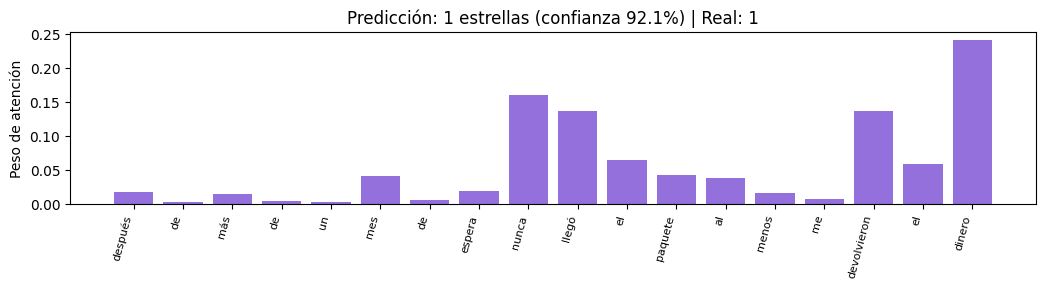

CASO MAL RESUELTO


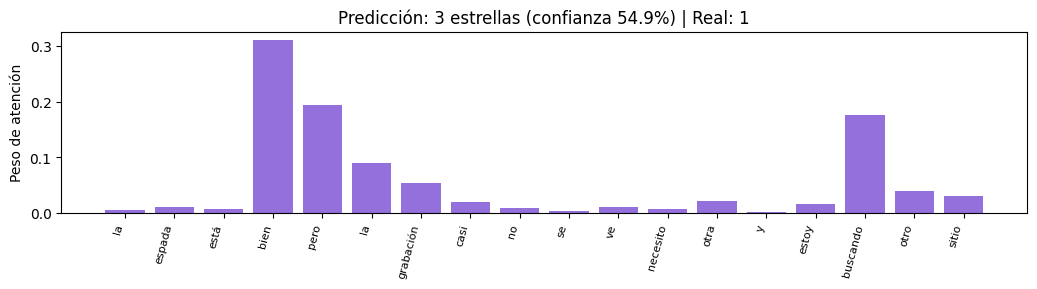

(3,
 array([0.01418956, 0.18370317, 0.5489337 , 0.22602536, 0.02714823],
       dtype=float32))

In [39]:
cortas = analisis[analisis['n_tokens'].between(8, 30)]
ejemplo_acierto = cortas[cortas['acierto']].iloc[0]
fallos = cortas[cortas['desviacion'].abs() >= 2]
ejemplo_error = fallos.iloc[0] if not fallos.empty else cortas[~cortas['acierto']].iloc[0]

print('CASO BIEN RESUELTO')
dibujar_atencion(ejemplo_acierto['text'], ejemplo_acierto['estrellas'])

print('CASO MAL RESUELTO')
dibujar_atencion(ejemplo_error['text'], ejemplo_error['estrellas'])

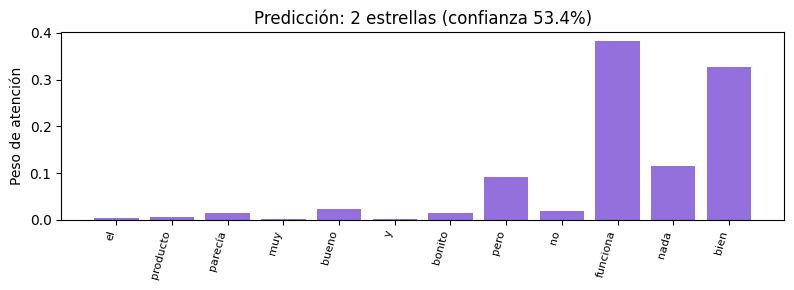

(2,
 array([3.1206414e-01, 5.3428805e-01, 1.4721707e-01, 5.9455400e-03,
        4.8517727e-04], dtype=float32))

In [40]:
# La negación al final invierte el sentido de todo lo anterior.
dibujar_atencion('el producto parecía muy bueno y bonito pero no funciona nada bien')

### Lo que se observa en los tres mapas de atención

**El caso bien resuelto se apoya en el vocabulario logístico.** En *"después de más de un mes de espera nunca llegó el paquete al menos me devolvieron el dinero"* acierta la calificación real de 1 estrella con un 92,1% de confianza, repartiendo el peso entre `dinero` (0,240), `nunca` (0,161), `llegó` (0,137) y `devolvieron` (0,137). Son casi las mismas palabras que la prueba chi cuadrado había señalado como características de una estrella, y ninguna de ellas valora el producto: todas se refieren al envío y al reembolso.

**Con la negación el modelo responde bien.** En *"el producto parecía muy bueno y bonito pero no funciona nada bien"* predice **2 estrellas**. El 83% de la atención se reparte entre `funciona` (0,383), `bien` (0,328) y `nada` (0,115), mientras que a `bueno` y `bonito` les asigna alrededor de 0,02: deja de lado la parte elogiosa y se queda con lo que viene después del *pero*.

Una bolsa de palabras no puede hacer esto: para TF-IDF, *bueno*, *bonito*, *no* y *bien* son cuatro características independientes cuyos pesos se suman, mientras que aquí la posición respecto al conector determina cuáles cuentan.

**El caso mal resuelto muestra el límite.** En *"la espada está bien pero la grabación casi no se ve, necesito otra y estoy buscando otro sitio"* (real 1 estrella, predicha 3), la atención máxima se la lleva `bien` (0,31), seguida de `pero` (0,195) y `buscando` (0,177). A la negación `no` le asigna **0,009**.

En el caso anterior la negación está pegada a lo que niega (*no funciona nada bien*) y el modelo la procesa; aquí aparece en una construcción más dispersa (*casi no se ve*) y la pierde. Sugiere que la red aprendió un patrón local de negación más que una regla sobre su alcance, aunque con dos ejemplos no podemos afirmarlo.

---
## 22. Predicción sobre reseñas nuevas

Probamos el modelo con textos escritos por nosotros, incluyendo tres casos difíciles: una reseña mixta, una irónica y una con la negación al final que invierte todo lo anterior.

In [41]:
@torch.no_grad()
def predecir_resena(texto, modelo=None):
    modelo = modelo or modelo_final
    modelo.eval().to(DEVICE)
    entrada = torch.tensor([texto_a_ids(texto)], dtype=torch.long).to(DEVICE)
    logits, _ = modelo(entrada)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    return {
        'estrellas': int(np.argmax(probs)) + 1,
        'confianza': float(probs.max()),
        'distribucion': {int(c): float(p) for c, p in zip(CLASES, probs)},
    }


PRUEBAS = [
    'Excelente calidad, llegó antes de lo previsto y funciona perfectamente.',
    'Se rompió a los tres días y el servicio de atención no responde. Una estafa.',
    'Cumple su función, nada del otro mundo pero por el precio está bien.',
    'El diseño es precioso y los materiales parecen buenos, pero no funciona.',
    'Maravilloso, si te gusta que te cobren cuarenta euros por un trozo de plástico.',
    'Lo compré con dudas y al final me ha sorprendido para bien.',
]

for texto in PRUEBAS:
    r = predecir_resena(texto)
    barra = ' '.join(f'{c}:{p:.0%}' for c, p in r['distribucion'].items())
    print(f"{r['estrellas']} estrellas (conf. {r['confianza']:.0%})  [{barra}]")
    print(f'   {texto}\n')

5 estrellas (conf. 85%)  [1:0% 2:0% 3:1% 4:14% 5:85%]
   Excelente calidad, llegó antes de lo previsto y funciona perfectamente.

1 estrellas (conf. 93%)  [1:93% 2:6% 3:1% 4:0% 5:0%]
   Se rompió a los tres días y el servicio de atención no responde. Una estafa.

4 estrellas (conf. 51%)  [1:0% 2:5% 3:35% 4:51% 5:8%]
   Cumple su función, nada del otro mundo pero por el precio está bien.

3 estrellas (conf. 39%)  [1:9% 2:39% 3:39% 4:11% 5:2%]
   El diseño es precioso y los materiales parecen buenos, pero no funciona.

3 estrellas (conf. 35%)  [1:3% 2:15% 3:35% 4:32% 5:15%]
   Maravilloso, si te gusta que te cobren cuarenta euros por un trozo de plástico.

3 estrellas (conf. 37%)  [1:5% 2:20% 3:37% 4:26% 5:13%]
   Lo compré con dudas y al final me ha sorprendido para bien.



### Comportamiento ante textos nuevos

Los seis casos se ordenan por dificultad y la **distribución de probabilidad resulta más informativa que la predicción**.

Los dos casos claros se resuelven con mucha seguridad: la reseña entusiasta obtiene 5 estrellas con un 85% de confianza y la indignada 1 estrella con un 93%.

El caso tibio —*"Cumple su función, nada del otro mundo pero por el precio está bien"*— recibe 4 estrellas con solo un 51%, repartiendo el resto entre 3 (35%) y 5 (8%). La predicción es defendible y **el modelo comunica que duda**.

Los tres casos difíciles muestran el límite:

- *"El diseño es precioso y los materiales parecen buenos, pero no funciona"* produce un **empate entre 2 y 3 estrellas (39% cada una)**. El modelo detecta el conflicto entre las dos mitades pero no lo resuelve. La respuesta razonable sería 1 o 2 estrellas.
- La reseña irónica —*"Maravilloso, si te gusta que te cobren cuarenta euros por un trozo de plástico"*— se clasifica como 3 estrellas con un 35%, casi empatada con las 4 (32%). **La ironía no se detecta**: requiere conocimiento del mundo y de la intención del hablante, no patrones léxicos ni de orden.
- *"Lo compré con dudas y al final me ha sorprendido para bien"* también cae en 3 estrellas con un 37%, cuando debería estar en 4 o 5.

En los tres fallos **la confianza cae por debajo del 40%**. La probabilidad de salida está razonablemente calibrada y podría usarse como filtro para derivar esos casos a revisión humana.

---
## 23. Guardado de los artefactos

Para reutilizar el modelo sin reentrenarlo hacen falta, además de los pesos, el vocabulario, la longitud de corte y la configuración de la arquitectura.

In [42]:
DIRECTORIO = Path('artefactos_resenas')
DIRECTORIO.mkdir(exist_ok=True)

torch.save(modelo_final.state_dict(), DIRECTORIO / 'modelo.pt')

metadatos = {
    'modelo': MEJOR_MODELO,
    'max_len': MAX_LEN,
    'pad_idx': PAD_IDX,
    'unk_idx': UNK_IDX,
    'clases': [int(c) for c in CLASES],
    'dim_embedding': int(DIM_EMB),
    'tam_vocabulario': len(vocabulario),
    'metricas_prueba': {k: float(v) for k, v in metricas_test.items()
                        if isinstance(v, (int, float))},
    'vocabulario': vocabulario,
}

with open(DIRECTORIO / 'metadatos.json', 'w', encoding='utf-8') as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print('Artefactos guardados en:', DIRECTORIO.resolve())

Artefactos guardados en: /content/artefactos_resenas


---
## 24. Demo interactiva

Una interfaz donde escribir una reseña y ver la calificación estimada, el reparto de probabilidad entre las cinco clases y las palabras en las que se apoyó el modelo. La distribución completa importa porque no es lo mismo predecir cuatro estrellas con el 90% de probabilidad que repartir entre tres y cuatro.

En Colab el servidor corre en la máquina virtual, que no es accesible desde el navegador, así que se genera además un enlace público temporal. La celda siguiente cierra el servidor.

In [47]:
import gradio as gr


def analizar(texto):
    if not texto or not texto.strip():
        return {}, 'Escribe una reseña para analizarla.'

    resultado = predecir_resena(texto)
    distribucion = {f'{c} estrellas': p for c, p in resultado['distribucion'].items()}

    if modelo_atencion is not None:
        tokens, pesos, _ = pesos_atencion(texto, modelo_atencion)
        relevantes = sorted(zip(tokens, pesos), key=lambda x: x[1], reverse=True)[:6]
        detalle = 'Palabras más atendidas: ' + ', '.join(f'{t} ({p:.0%})' for t, p in relevantes)
    else:
        detalle = ''

    return distribucion, detalle


demo = gr.Interface(
    fn=analizar,
    inputs=gr.Textbox(lines=4, label='Reseña', placeholder='Escribe aquí una reseña en español...'),
    outputs=[gr.Label(num_top_classes=5, label='Calificación estimada'),
             gr.Textbox(label='En qué se fijó el modelo')],
    title='Estimador de calificación de reseñas en español',
    description='Predice cuántas estrellas corresponden a una reseña y muestra en qué palabras se apoya.',
    examples=[[t] for t in PRUEBAS[:4]],
    flagging_mode='never',
)

# En Colab el servidor local no es accesible desde el navegador: share genera un enlace público.
demo.launch(share=IN_COLAB, inline=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0f7ec8cd8d30cbbca1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [48]:
demo.close()

Closing server running on port: 7861


---
## 25. Resultados y conclusiones

In [45]:
print('=' * 72)
print('BALANCE DEL EXPERIMENTO')
print('=' * 72)

print(f'\nCorpus: {len(train_df)} reseñas de entrenamiento, {len(val_df)} de validación, '
      f'{len(test_df)} de prueba')
print(f'Vocabulario: {len(vocabulario)} términos | Longitud de corte: {MAX_LEN} tokens')
print(f'Cobertura de vectores preentrenados: {cobertura:.1%}')

print('\nDesempeño en validación:')
print(tabla[['modelo', 'f1_macro', 'mae_estrellas', 'qwk']].round(4).to_string(index=False))

print(f'\nModelo seleccionado: {MEJOR_MODELO}')
print('\nResultado en prueba:')
for clave in ['accuracy', 'f1_macro', 'mae_estrellas', 'qwk']:
    print(f'   {clave:15s} {metricas_test[clave]:.4f}')

print('\nDistribución del error en prueba:')
print(f'   acierto exacto           {exactos:.1%}')
print(f'   dentro de una estrella   {vecinos:.1%}')
print(f'   desviación de 2 o más    {graves:.1%}')
print(f'   sesgo medio              {error_con_signo.mean():+.3f} estrellas')

BALANCE DEL EXPERIMENTO

Corpus: 50000 reseñas de entrenamiento, 4995 de validación, 4994 de prueba
Vocabulario: 19551 términos | Longitud de corte: 73 tokens
Cobertura de vectores preentrenados: 97.1%

Desempeño en validación:
                   modelo  f1_macro  mae_estrellas    qwk
          TF-IDF + LogReg    0.5072         0.6360 0.7484
                      GRU    0.5045         0.6186 0.7693
          LSTM + atención    0.5010         0.6340 0.7592
                   BiLSTM    0.4994         0.6338 0.7560
GRU + vectores congelados    0.4875         0.6396 0.7631
GRU + vectores ajustables    0.4846         0.6476 0.7555
                     LSTM    0.1904         1.4739 0.3385

Modelo seleccionado: GRU

Resultado en prueba:
   accuracy        0.5050
   f1_macro        0.5066
   mae_estrellas   0.6037
   qwk             0.7798

Distribución del error en prueba:
   acierto exacto           50.5%
   dentro de una estrella   91.2%
   desviación de 2 o más    8.8%
   sesgo medio      

### Conclusiones

**1. La respuesta a la pregunta de investigación depende de la métrica.**

En F1-macro el modelo lineal gana por 0,0027: **el orden de las palabras no ayudó a acertar más veces**. En MAE la GRU mejora en 0,017 estrellas y en QWK en 0,021: **sí redujo la gravedad de los errores**. La diferencia está en la distancia a la que se quedan cuando fallan.

**2. Las métricas ordinales cambiaron la lectura del experimento.**

Evaluando solo con Accuracy y F1 habríamos concluido que las redes recurrentes no aportan nada. Con MAE y QWK aparece una diferencia pequeña pero sistemática en las dos métricas que tienen en cuenta el orden de las clases.

**3. Varias observaciones del análisis exploratorio se corresponden con los resultados.**

El índice de Jaccard mostraba que las calificaciones contiguas comparten hasta el 73% de su vocabulario; la matriz de confusión tiene casi todo el error junto a la diagonal y **0,00 y 0,01 entre extremos opuestos**. Las palabras discriminativas mostraban que la clase de tres estrellas se define por matizadores, y es la peor clasificada (F1 de 0,4054).

**4. Los vectores preentrenados empeoraron el resultado.**

Las dos variantes con vectores de spaCy caen a 0,4875 y 0,4846 frente a 0,5045, pese a una cobertura del 97,1%. Ese espacio sitúa *bueno* y *malo* a 0,758 de similitud y *caro* y *barato* a 0,787, porque se estima por contexto de uso: sirve para saber de qué se habla más que qué se opina. Con 50.000 ejemplos etiquetados hay señal suficiente para aprender embeddings del propio dominio.

**5. La LSTM no llegó a entrenarse.**

Se quedó en 0,1904 de F1 con la pérdida plana durante ocho épocas, mientras la GRU, con menos parámetros y en menos tiempo, obtuvo el mejor resultado, con los mismos datos, la misma semilla y el mismo procedimiento. Sobre el papel la LSTM tiene más capacidad, pero comprimir 73 pasos en un único estado final sin recorte de gradiente la hace más frágil. Una arquitectura más potente no sirve si no se consigue entrenarla.

**6. Parte del techo de desempeño viene de los datos.**

La auditoría encontró 398 textos idénticos con más de una calificación y, de las 57 reseñas presentes a la vez en entrenamiento y prueba, **solo 17 llevaban la misma nota**. El análisis de errores apunta igual: *"Mala calidad, solo funciona la mitad, nada recomendable"* está etiquetada con tres estrellas. Si dos ejemplos idénticos tienen etiquetas distintas, ningún clasificador puede acertar en ambos.

**7. El modelo es más útil de lo que sugiere su acierto exacto.**

Un 50,5% suena mediocre, pero el **91,2% de las predicciones cae a menos de una estrella del valor real**, solo el 8,8% se desvía dos o más y el sesgo medio es de −0,045 estrellas. Además la confianza es informativa: 0,570 de media en aciertos frente a 0,489 en errores, y baja del 40% en los casos que no resuelve.

**8. La atención fue más útil para entender que para mejorar.**

Su efecto sobre el F1 fue pequeño (0,5010 frente a 0,5045 de la GRU), pero permitió observar el reparto de peso entre palabras: ante *"parecía muy bueno y bonito pero no funciona nada bien"* concentra la atención después del conector y acierta, mientras que en *"la grabación casi no se ve"* asigna 0,009 a la negación y falla.